# MangoXPPNet: Complete Research Notebook
## Mango Leaf Disease & Pest Classification using Advanced CNN Architecture

**Author**: Md Imdadul Islam  
**Date**: November 10, 2025  
**Architecture**: MangoXPPNet (Ghost Modules + SE Blocks + ECA Attention)

---

###  Table of Contents
1. **Setup & Configuration** - Import libraries and set paths
2. **Exploratory Data Analysis (EDA)** - Dataset structure, class distribution, sample visualization
3. **Data Preprocessing** - CLAHE, normalization, augmentation strategies
4. **Model Architecture** - MangoXPPNet implementation with Ghost modules, SE blocks
5. **Training Pipeline** - Model compilation, callbacks, training loop
6. **Model Evaluation** - Confusion matrix, classification report, visualizations
7. **Predictions & Inference** - Test on new images
8. **Results Analysis** - Performance metrics and comparison

---

###  Datasets Covered
- **MangoLeafBD**: Mango leaf diseases (uses CLAHE preprocessing)
- **MangoPest**: Mango pests (basic normalization)
- **MLDID**: Mango Leaf Disease Image Dataset (basic normalization)
- **MangoPest_v1**: Alternative pest dataset

---

## 1. Setup & Configuration

### Import Required Libraries

In [1]:
# Core libraries
import os
import sys
import json
import time
import random
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, Dense, Dropout,
    BatchNormalization, Activation, GlobalAveragePooling2D,
    MaxPool2D, Add, Multiply, Reshape, Concatenate
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard
from tensorflow.keras.optimizers import SGD, Adam

# Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, precision_recall_fscore_support
)

# Suppress warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

✅ All libraries imported successfully!
TensorFlow version: 2.15.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Set Random Seeds for Reproducibility

In [2]:
# Set seed for reproducibility
SEED = 42

def set_seed(seed_value=42):
    """Set seed for reproducibility across all libraries"""
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)
    
set_seed(SEED)
print(f"✅ Random seed set to {SEED} for reproducibility")

✅ Random seed set to 42 for reproducibility


### Configure Paths

**IMPORTANT**: Update these paths based on your dataset selection:
- **MangoLeafBD**: Mango leaf diseases (8 classes)
- **MangoPest**: Mango pests (7 classes) 
- **MangoPest_v1**: Alternative pest dataset
- **MLDID**: Mango Leaf Disease Image Dataset (8 classes)

In [4]:
# ============================================
# PATH CONFIGURATION (STANDARDIZED)
# ============================================

from pathlib import Path
from datetime import datetime

# 1) Identify dataset + model for this notebook
DATASET_NAME = 'MangoLeafBD'   # Dataset for this notebook
MODEL_NAME   = 'MangoXPPNet'   # Model architecture name

# 2) Project root - MangoXPPNet_Research_Notebook workspace
WORKSPACE_DIR = Path('/Users/invictus/Desktop/Thesis project/thesis_draft')

# 3) Datasets (via symbolic link in workspace)
DATASETS_BASE = WORKSPACE_DIR / 'datasets'
DATA_DIR  = DATASETS_BASE / DATASET_NAME / 'processed'
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = DATA_DIR / 'val'
TEST_DIR  = DATA_DIR / 'test'

# 4) Experiments and outputs save to THIS workspace
EXPERIMENTS_ROOT = WORKSPACE_DIR / DATASET_NAME / 'experiments'
OUTPUTS_ROOT     = WORKSPACE_DIR / DATASET_NAME / 'outputs'

# 5) Helper to create incrementing run directories
def get_next_run_dir(parent_dir, prefix='run_'):
    """Finds the next available run directory (run_1, run_2, ...)"""
    parent_dir = Path(parent_dir)
    parent_dir.mkdir(parents=True, exist_ok=True)
    existing = [d for d in parent_dir.iterdir()
                if d.is_dir() and d.name.startswith(prefix)]
    nums = [int(d.name[len(prefix):]) for d in existing
            if d.name[len(prefix):].isdigit()]
    next_num = max(nums) + 1 if nums else 1
    return parent_dir / f'{prefix}{next_num}'

# 6) Model-aware directory structure
EXPERIMENTS_BASE = EXPERIMENTS_ROOT / MODEL_NAME
OUTPUTS_BASE     = OUTPUTS_ROOT / MODEL_NAME

EXPERIMENT_DIR = WORKSPACE_DIR / DATASET_NAME / 'experiments' / MODEL_NAME / 'run_8'
#EXPERIMENT_DIR = get_next_run_dir(EXPERIMENTS_BASE)  
OUTPUT_DIR     = WORKSPACE_DIR / DATASET_NAME / 'outputs' / MODEL_NAME / 'run_8'
#OUTPUT_DIR     = get_next_run_dir(OUTPUTS_BASE)       
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Display configuration
print("="*60)
print("📁 PATH CONFIGURATION")
print("="*60)
print(f"Workspace      : {WORKSPACE_DIR}")
print(f"Dataset Name   : {DATASET_NAME}")
print(f"Model Name     : {MODEL_NAME}")
print(f"Data Directory : {DATA_DIR}")
print(f"Train Directory: {TRAIN_DIR}")
print(f"Val Directory  : {VAL_DIR}")
print(f"Test Directory : {TEST_DIR}")
print(f"Experiment Dir : {EXPERIMENT_DIR}")
print(f"Output Dir     : {OUTPUT_DIR}")
print("="*60)

# Verify paths exist
for name, path in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    if path.exists():
        print(f"✅ {name} directory exists")
    else:
        print(f"❌ {name} directory NOT FOUND: {path}")


📁 PATH CONFIGURATION
Workspace      : /Users/invictus/Desktop/Thesis project/thesis_draft
Dataset Name   : MangoLeafBD
Model Name     : MangoXPPNet
Data Directory : /Users/invictus/Desktop/Thesis project/thesis_draft/datasets/MangoLeafBD/processed
Train Directory: /Users/invictus/Desktop/Thesis project/thesis_draft/datasets/MangoLeafBD/processed/train
Val Directory  : /Users/invictus/Desktop/Thesis project/thesis_draft/datasets/MangoLeafBD/processed/val
Test Directory : /Users/invictus/Desktop/Thesis project/thesis_draft/datasets/MangoLeafBD/processed/test
Experiment Dir : /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/experiments/MangoXPPNet/run_8
Output Dir     : /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/MangoXPPNet/run_8
✅ Train directory exists
✅ Val directory exists
✅ Test directory exists


## 2. Exploratory Data Analysis (EDA)

### 2.1 Dataset Structure Analysis

In [5]:
def analyze_dataset_structure(base_dir):
    """Analyze and display dataset directory structure"""
    
    data = {
        'Split': [],
        'Class': [],
        'Count': [],
        'Path': []
    }
    
    for split in ['train', 'val', 'test']:
        split_dir = base_dir / split
        if not split_dir.exists():
            continue
            
        # Get class directories
        class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])
        
        for class_dir in class_dirs:
            class_name = class_dir.name
            # Count images
            image_files = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpeg'))
            count = len(image_files)
            
            data['Split'].append(split)
            data['Class'].append(class_name)
            data['Count'].append(count)
            data['Path'].append(str(class_dir))
    
    df = pd.DataFrame(data)
    return df

# Analyze dataset
print("=" * 80)
print(f"📊 DATASET STRUCTURE ANALYSIS: {DATASET_NAME}")
print("=" * 80)

df_structure = analyze_dataset_structure(DATA_DIR)
print(df_structure.to_string(index=False))

# Summary statistics
print("\n" + "=" * 80)
print("📈 SUMMARY STATISTICS")
print("=" * 80)
summary = df_structure.groupby('Split')['Count'].agg(['sum', 'mean', 'min', 'max'])
print(summary)

# Total images
total_images = df_structure['Count'].sum()
print(f"\n📌 Total Images: {total_images:,}")
print(f"📌 Number of Classes: {df_structure['Class'].nunique()}")
print(f"📌 Classes: {sorted(df_structure['Class'].unique())}")

📊 DATASET STRUCTURE ANALYSIS: MangoLeafBD
Split            Class  Count                                                                                                      Path
train      Anthracnose    400      /Users/invictus/Desktop/Thesis project/thesis_draft/datasets/MangoLeafBD/processed/train/Anthracnose
train Bacterial Canker    400 /Users/invictus/Desktop/Thesis project/thesis_draft/datasets/MangoLeafBD/processed/train/Bacterial Canker
train   Cutting Weevil    400   /Users/invictus/Desktop/Thesis project/thesis_draft/datasets/MangoLeafBD/processed/train/Cutting Weevil
train         Die Back    400         /Users/invictus/Desktop/Thesis project/thesis_draft/datasets/MangoLeafBD/processed/train/Die Back
train       Gall Midge    400       /Users/invictus/Desktop/Thesis project/thesis_draft/datasets/MangoLeafBD/processed/train/Gall Midge
train          Healthy    400          /Users/invictus/Desktop/Thesis project/thesis_draft/datasets/MangoLeafBD/processed/train/Healthy
train 

### 2.2 Class Distribution Visualization

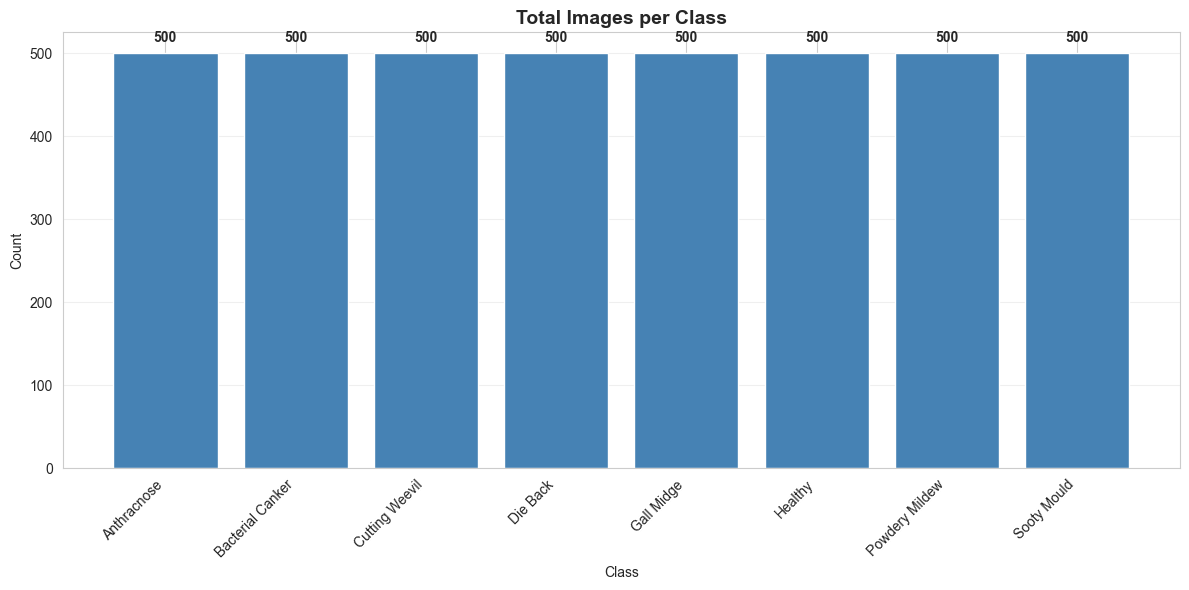

✅ Class distribution plot saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/MangoXPPNet/run_8/class_distribution.png


In [6]:
# Visualize class distribution across splits
df_total = df_structure.groupby('Class')['Count'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(range(len(df_total)), df_total.values, color='steelblue')
plt.xticks(range(len(df_total)), df_total.index, rotation=45, ha='right')
plt.title('Total Images per Class', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Class')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(df_total.values):
    plt.text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Class distribution plot saved to: {OUTPUT_DIR / 'class_distribution.png'}")

### 2.3 Sample Image Visualization

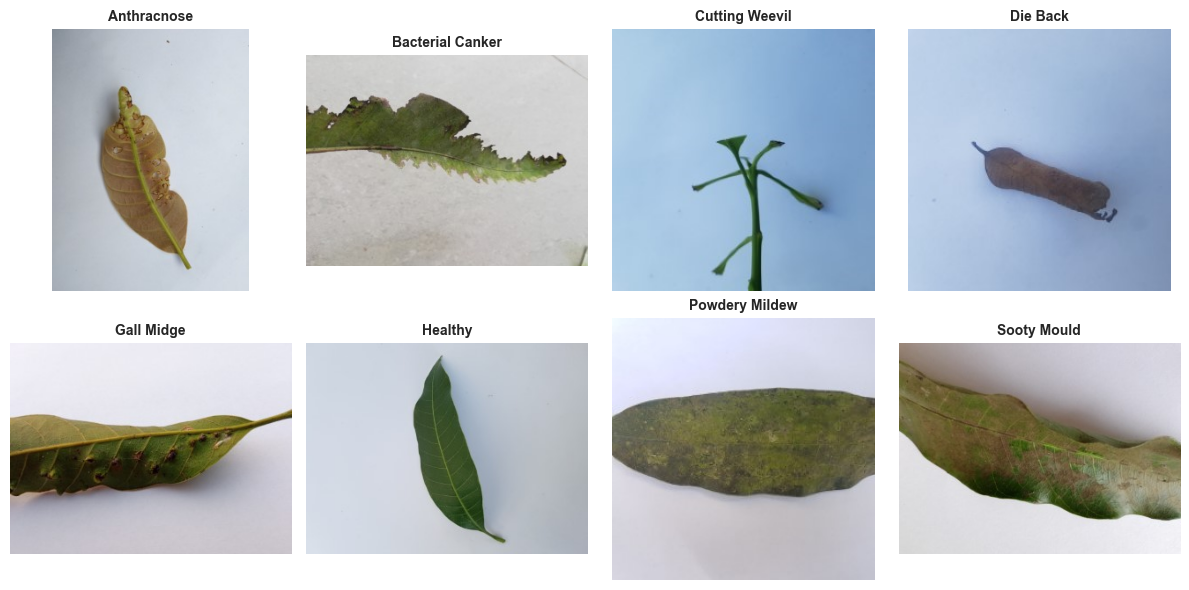

✅ Sample images saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/MangoXPPNet/run_8/sample_images_train.png


In [7]:
split_dir = DATA_DIR / 'train'
class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])

n_classes = len(class_dirs)
n_cols = (n_classes + 1) // 2
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))

axes = axes.flatten() if n_classes > 1 else [axes]

for i, class_dir in enumerate(class_dirs):
    class_name = class_dir.name
    image_files = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpeg'))
    if image_files:
        img_path = random.choice(image_files)
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(class_name, fontsize=10, fontweight='bold')
        axes[i].axis('off')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_images_train.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Sample images saved to: {OUTPUT_DIR / 'sample_images_train.png'}")

## 3. Data Preprocessing

### 3.1 Preprocessing Functions (CLAHE for MangoLeafBD, Basic Normalization for Others)

In [8]:
def preprocess_mango_leaf_bd(img):
    """
    Apply Gaussian blur + CLAHE (for MangoLeafBD).
    Input: float32 RGB [0-255] from ImageDataGenerator
    Output: float32 RGB [0-1] (normalized)
    """
    if not isinstance(img, np.ndarray):
        img = np.array(img)
    if img.shape[-1] == 4:
        img = img[..., :3]
    
    # Convert float32 [0-255] to uint8 [0-255] for OpenCV
    if img.dtype == np.float32 or img.dtype == np.float64:
        img = np.clip(img, 0, 255).astype('uint8')
    
    # Apply blur + CLAHE
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img_blur = cv2.GaussianBlur(img_bgr, (3, 3), 0)
    lab = cv2.cvtColor(img_blur, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l2 = clahe.apply(l)
    lab = cv2.merge((l2, a, b))
    img_out = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    img_out = cv2.cvtColor(img_out, cv2.COLOR_BGR2RGB)
    
    # Normalize to [0-1] and return as float32
    return img_out.astype('float32') / 255.0

def preprocess_basic(img):
    """
    Identity preprocessing with normalization (for MangoPest & MLDID).
    Input: uint8 RGB [0-255]
    Output: float32 RGB [0-1] (normalized)
    """
    if not isinstance(img, np.ndarray):
        img = np.array(img)
    if img.shape[-1] == 4:
        img = img[..., :3]
    # Normalize to [0-1]
    return img.astype('float32') / 255.0

def get_preprocessing_fn(dataset_name: str):
    """Return correct preprocessing function based on dataset name."""
    name = dataset_name.lower()
    if "mangoleafbd" in name or "bd" in name:
        print("✅ Using CLAHE preprocessing (Gaussian Blur + CLAHE)")
        return preprocess_mango_leaf_bd
    else:
        print("✅ Using basic normalization preprocessing")
        return preprocess_basic

# Get preprocessing function for current dataset
preprocessing_fn = get_preprocessing_fn(DATASET_NAME)

✅ Using CLAHE preprocessing (Gaussian Blur + CLAHE)


### 3.2 Visualize Preprocessing Effects

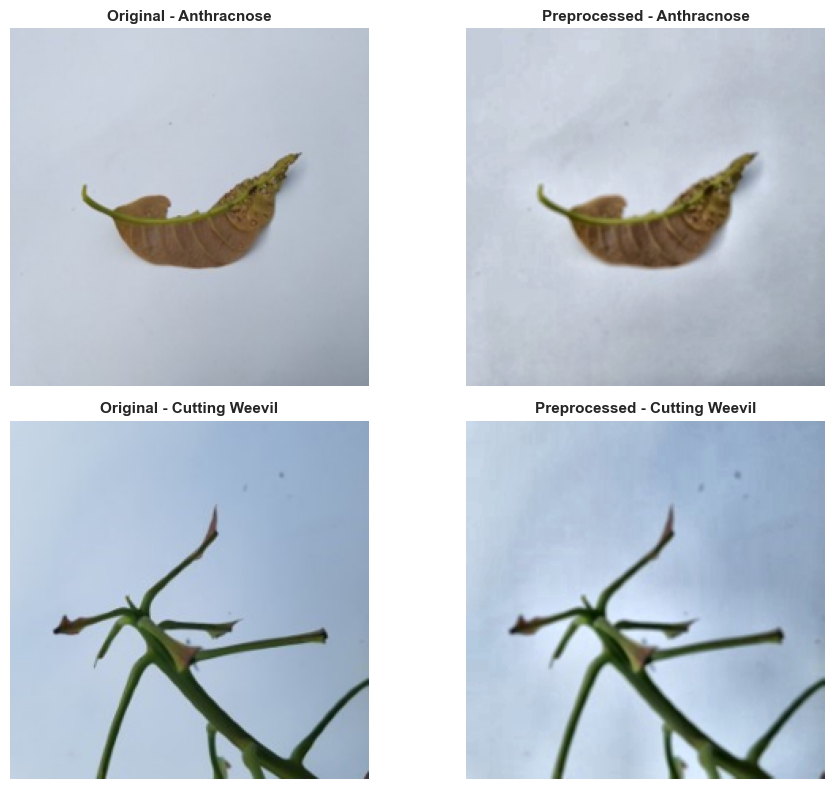

✅ Preprocessing comparison saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/MangoXPPNet/run_8/preprocessing_comparison.png


In [10]:
split_dir = DATA_DIR / 'train'
class_dirs = [d for d in split_dir.iterdir() if d.is_dir()]

sample_images = []
for class_dir in random.sample(class_dirs, min(2, len(class_dirs))):
    img_files = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png'))
    if img_files:
        sample_images.append((random.choice(img_files), class_dir.name))

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, (img_path, class_name) in enumerate(sample_images):
    img_orig = np.array(Image.open(img_path).resize((227, 227)))
    img_prep = preprocessing_fn(img_orig.copy())
    
    axes[i, 0].imshow(img_orig)
    axes[i, 0].set_title(f'Original - {class_name}', fontsize=11, fontweight='bold')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(img_prep)
    axes[i, 1].set_title(f'Preprocessed - {class_name}', fontsize=11, fontweight='bold')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'preprocessing_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Preprocessing comparison saved to: {OUTPUT_DIR / 'preprocessing_comparison.png'}")

### 3.3 Data Augmentation Configuration

In [11]:
# Hyperparameters
INPUT_HEIGHT = 227
INPUT_WIDTH = 227
BATCH_SIZE = 12
EPOCHS = 100
LEARNING_RATE = 0.001
DROPOUT_RATE = 0.3
PATIENCE = 15

print("=" * 60)
print("⚙️  HYPERPARAMETERS")
print("=" * 60)
print(f"Input Size     : {INPUT_HEIGHT}x{INPUT_WIDTH}")
print(f"Batch Size     : {BATCH_SIZE}")
print(f"Epochs         : {EPOCHS}")
print(f"Learning Rate  : {LEARNING_RATE}")
print(f"Dropout Rate   : {DROPOUT_RATE}")
print(f"Patience       : {PATIENCE}")
print("=" * 60)

# Create data generators with augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocessing_fn,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocessing_fn
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocessing_fn
)

print("\n✅ Data augmentation configured:")
print("   • Rotation: ±20°")
print("   • Width/Height shift: 10%")
print("   • Zoom: 10%")
print("   • Horizontal flip: Yes")
print("   • Brightness: 80-120%")

⚙️  HYPERPARAMETERS
Input Size     : 227x227
Batch Size     : 12
Epochs         : 100
Learning Rate  : 0.001
Dropout Rate   : 0.3
Patience       : 15

✅ Data augmentation configured:
   • Rotation: ±20°
   • Width/Height shift: 10%
   • Zoom: 10%
   • Horizontal flip: Yes
   • Brightness: 80-120%


### 3.4 Create Data Generators

In [12]:
# Create training generator
train_generator = train_datagen.flow_from_directory(
    str(TRAIN_DIR),
    target_size=(INPUT_HEIGHT, INPUT_WIDTH),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

# Create validation generator
val_generator = val_datagen.flow_from_directory(
    str(VAL_DIR),
    target_size=(INPUT_HEIGHT, INPUT_WIDTH),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

# Create test generator
test_generator = test_datagen.flow_from_directory(
    str(TEST_DIR),
    target_size=(INPUT_HEIGHT, INPUT_WIDTH),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Get number of classes
n_classes = len(train_generator.class_indices)

# Lock class order: save as list in index order
idx2name = [None] * n_classes
for name, idx in train_generator.class_indices.items():
    idx2name[idx] = name

print("\n" + "=" * 60)
print("📚 DATA GENERATORS CREATED")
print("=" * 60)
print(f"Number of Classes: {n_classes}")
print(f"Class Order: {idx2name}")
print(f"\nTraining samples  : {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples      : {test_generator.samples}")
print(f"\nSteps per epoch (train): {len(train_generator)}")
print(f"Steps per epoch (val)  : {len(val_generator)}")
print("=" * 60)

# Save classes.json
with open(EXPERIMENT_DIR / 'classes.json', 'w') as f:
    json.dump(idx2name, f, indent=2)

print(f"\n✅ Class order saved to: {EXPERIMENT_DIR / 'classes.json'}")

Found 3200 images belonging to 8 classes.
Found 400 images belonging to 8 classes.
Found 400 images belonging to 8 classes.

📚 DATA GENERATORS CREATED
Number of Classes: 8
Class Order: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']

Training samples  : 3200
Validation samples: 400
Test samples      : 400

Steps per epoch (train): 267
Steps per epoch (val)  : 34

✅ Class order saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/experiments/MangoXPPNet/run_8/classes.json


## 4. MangoXPPNet Model Architecture

### 4.1 Building Blocks: Ghost Module, SE Block, ECA Block

In [13]:
# SE Block (Squeeze-and-Excitation)
def se_block(x, r=16, name="se"):
    """
    Squeeze-and-Excitation block for channel attention
    Args:
        x: Input tensor
        r: Reduction ratio (default: 16)
        name: Block name
    """
    c = x.shape[-1]
    s = GlobalAveragePooling2D(name=f"{name}_gap")(x)
    s = Reshape((1, 1, c))(s)
    s = Dense(max(c // r, 8), activation='relu', name=f"{name}_fc1")(s)
    s = Dense(c, activation='sigmoid', name=f"{name}_fc2")(s)
    return Multiply(name=f"{name}_scale")([x, s])

# ECA Block (Efficient Channel Attention)
def eca_block(x, k=3, name="eca"):
    """
    Efficient Channel Attention (lighter than SE)
    Args:
        x: Input tensor
        k: Kernel size for 1D convolution
        name: Block name
    """
    c = x.shape[-1]
    y = GlobalAveragePooling2D(name=f"{name}_gap")(x)
    y = Reshape((c, 1))(y)
    y = tf.keras.layers.Conv1D(1, k, padding='same', use_bias=False, name=f"{name}_conv")(y)
    y = Activation('sigmoid', name=f"{name}_sig")(y)
    y = Reshape((1, 1, c))(y)
    return Multiply(name=f"{name}_scale")([x, y])

# Ghost Module
def ghost_module(x, out_channels, kernel_size, s=1, ratio=2, name="ghost"):
    """
    Ghost module for efficient feature extraction
    Args:
        x: Input tensor
        out_channels: Number of output channels
        kernel_size: Convolution kernel size
        s: Stride
        ratio: Ghost ratio (default: 2)
        name: Module name
    """
    init_channels = int(tf.math.ceil(out_channels / ratio))
    
    # Primary convolution
    p = Conv2D(init_channels, kernel_size, strides=s, padding='same', 
               use_bias=False, name=f"{name}_prim_conv")(x)
    p = BatchNormalization(name=f"{name}_prim_bn")(p)
    p = Activation('relu', name=f"{name}_prim_act")(p)
    
    # Cheap operation (depthwise convolution)
    c = DepthwiseConv2D(3, strides=1, padding='same', use_bias=False, 
                       name=f"{name}_cheap_dw")(p)
    c = BatchNormalization(name=f"{name}_cheap_bn")(c)
    c = Activation('relu', name=f"{name}_cheap_act")(c)
    
    # Concatenate
    y = Concatenate(name=f"{name}_concat")([p, c])
    
    # Align channels if needed
    if y.shape[-1] != out_channels:
        y = Conv2D(out_channels, 1, padding='same', use_bias=False, 
                  name=f"{name}_align")(y)
        y = BatchNormalization(name=f"{name}_align_bn")(y)
    
    return y

# Bottleneck Block
def bottleneck(x, exp, out_ch, s=1, se=True, name="bneck"):
    """
    MobileNetV3-style bottleneck with optional SE block
    Args:
        x: Input tensor
        exp: Expansion channels
        out_ch: Output channels
        s: Stride
        se: Use SE block (default: True)
        name: Block name
    """
    in_ch = x.shape[-1]
    
    # Expansion
    y = Conv2D(exp, 1, padding='same', use_bias=False, name=f"{name}_expand")(x)
    y = BatchNormalization(name=f"{name}_expand_bn")(y)
    y = Activation('relu', name=f"{name}_expand_act")(y)
    
    # Depthwise
    y = DepthwiseConv2D(3, strides=s, padding='same', use_bias=False, 
                       name=f"{name}_dw")(y)
    y = BatchNormalization(name=f"{name}_dw_bn")(y)
    y = Activation('relu', name=f"{name}_dw_act")(y)
    
    # Projection
    y = Conv2D(out_ch, 1, padding='same', use_bias=False, name=f"{name}_proj")(y)
    y = BatchNormalization(name=f"{name}_proj_bn")(y)
    
    # SE block
    if se:
        y = se_block(y, name=f"{name}_se")
    
    # Residual connection
    if s == 1 and in_ch == out_ch:
        y = Add(name=f"{name}_add")([x, y])
    
    return y

print("✅ Building blocks defined:")
print("   • SE Block (Squeeze-and-Excitation)")
print("   • ECA Block (Efficient Channel Attention)")
print("   • Ghost Module")
print("   • Bottleneck with Residual Connection")

✅ Building blocks defined:
   • SE Block (Squeeze-and-Excitation)
   • ECA Block (Efficient Channel Attention)
   • Ghost Module
   • Bottleneck with Residual Connection


### 4.2 Build Complete MangoXPPNet Architecture

In [14]:
def MangoXPPNet(input_shape=(227, 227, 3), n_classes=8, dropout_rate=0.3):
    """
    MangoXPPNet: Advanced CNN architecture for mango disease classification
    
    Features:
    - Ghost modules for efficient feature extraction
    - SE blocks for channel attention
    - ECA blocks for lightweight attention
    - Residual bottleneck for deep feature learning
    - GELU activation in classification head
    
    Args:
        input_shape: Input image shape (default: 227x227x3)
        n_classes: Number of output classes
        dropout_rate: Dropout rate (default: 0.3)
    
    Returns:
        Keras Model
    """
    inp = Input(shape=input_shape, name='input')
    
    # Stem - Group 1
    x = ghost_module(inp, 64, 7, s=2, name='g1')
    x = se_block(x, name='g1_se')
    
    # Group 2
    x = ghost_module(x, 128, 5, s=1, name='g2')
    x = BatchNormalization(name='g2_bn')(x)
    x = Activation('relu', name='g2_act')(x)
    x = MaxPool2D(pool_size=3, strides=2, padding='same', name='g2_pool')(x)
    x = se_block(x, name='g2_se')
    
    # Group 3
    x = ghost_module(x, 256, 3, s=1, name='g3')
    x = BatchNormalization(name='g3_bn')(x)
    x = Activation('relu', name='g3_act')(x)
    x = eca_block(x, k=3, name='g3_eca')
    
    # Residual bottleneck
    x = bottleneck(x, exp=256, out_ch=512, s=1, se=True, name='rb1')
    
    # Final conv blocks
    x = Conv2D(512, 3, padding='same', use_bias=False, name='conv4')(x)
    x = BatchNormalization(name='conv4_bn')(x)
    x = Activation('relu', name='conv4_act')(x)
    x = MaxPool2D(pool_size=2, strides=2, padding='same', name='conv4_pool')(x)
    
    x = Conv2D(256, 3, padding='same', use_bias=False, name='conv5')(x)
    x = BatchNormalization(name='conv5_bn')(x)
    x = Activation('relu', name='conv5_act')(x)
    
    # Classification head
    x = GlobalAveragePooling2D(name='gap')(x)
    x = Dense(256, activation='gelu', name='fc1')(x)
    x = Dropout(dropout_rate, name='drop')(x)
    out = Dense(n_classes, activation='softmax', name='fc_out')(x)
    
    return Model(inp, out, name='MangoXPPNet')


def build_model(input_shape, num_classes, dropout_rate=0.3):
    """
    Build and return a compiled model based on MODEL_NAME.
    
    Currently builds MangoXPPNet custom architecture.
    
    Later, for pretrained models like VGG16 or ResNet50, we will:
    - Change MODEL_NAME = 'VGG16' or 'ResNet50' in the config block
    - Implement different build logic here based on MODEL_NAME:
        if MODEL_NAME == 'VGG16':
            base = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
            ...
        elif MODEL_NAME == 'ResNet50':
            base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
            ...
        elif MODEL_NAME == 'MangoXPPNet':
            return MangoXPPNet(input_shape, num_classes, dropout_rate)
    
    Args:
        input_shape: Input image shape (height, width, channels)
        num_classes: Number of output classes
        dropout_rate: Dropout rate for regularization
        
    Returns:
        Compiled Keras Model
    """
    # For now, we only build MangoXPPNet
    return MangoXPPNet(input_shape=input_shape, n_classes=num_classes, dropout_rate=dropout_rate)


# Build model using the build_model function
print("\n" + "=" * 60)
print(f"🏗️  BUILDING {MODEL_NAME} MODEL")
print("=" * 60)

model = build_model(
    input_shape=(INPUT_HEIGHT, INPUT_WIDTH, 3),
    num_classes=n_classes,
    dropout_rate=DROPOUT_RATE
)

print("\n✅ Model built successfully!")
print(f"   • Model Architecture: {MODEL_NAME}")
print(f"   • Input Shape: {INPUT_HEIGHT}x{INPUT_WIDTH}x3")
print(f"   • Number of Classes: {n_classes}")
print(f"   • Dropout Rate: {DROPOUT_RATE}")


🏗️  BUILDING MangoXPPNet MODEL


2025-12-01 04:11:23.594048: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-12-01 04:11:23.594131: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-01 04:11:23.594150: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-12-01 04:11:23.594257: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-01 04:11:23.594295: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



✅ Model built successfully!
   • Model Architecture: MangoXPPNet
   • Input Shape: 227x227x3
   • Number of Classes: 8
   • Dropout Rate: 0.3


### 4.3 Model Summary & Architecture Visualization

In [15]:
# Display model summary
print("\n" + "=" * 80)
print("📊 MODEL SUMMARY")
print("=" * 80)
model.summary()

# Count total parameters
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])

print("\n" + "=" * 60)
print("📈 MODEL STATISTICS")
print("=" * 60)
print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print(f"Model Size (approx)  : {total_params * 4 / (1024**2):.2f} MB")
print("=" * 60)


📊 MODEL SUMMARY
Model: "MangoXPPNet"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, 227, 227, 3)]        0         []                            
                                                                                                  
 g1_prim_conv (Conv2D)       (None, 114, 114, 32)         4704      ['input[0][0]']               
                                                                                                  
 g1_prim_bn (BatchNormaliza  (None, 114, 114, 32)         128       ['g1_prim_conv[0][0]']        
 tion)                                                                                            
                                                                                                  
 g1_prim_act (Activation)    (None, 114, 114, 32)         0         ['g

## 5. Model Compilation & Training

### 5.1 Compile Model

In [16]:
# Compile model with SGD optimizer
optimizer = SGD(learning_rate=LEARNING_RATE, momentum=0.9, nesterov=True)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled successfully!")
print(f"   • Optimizer: SGD (Nesterov Momentum)")
print(f"   • Learning Rate: {LEARNING_RATE}")
print(f"   • Loss: Categorical Crossentropy")
print(f"   • Metrics: Accuracy")

✅ Model compiled successfully!
   • Optimizer: SGD (Nesterov Momentum)
   • Learning Rate: 0.001
   • Loss: Categorical Crossentropy
   • Metrics: Accuracy


### 5.2 Setup Callbacks

In [17]:
# Model checkpoint path - uses MODEL_NAME variable
model_filename = f"{MODEL_NAME}_{DATASET_NAME}_best.h5"
model_path = EXPERIMENT_DIR / model_filename

# Setup callbacks
callbacks = [
    ModelCheckpoint(
        filepath=str(model_path),
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("=" * 60)
print("🔧 TRAINING CALLBACKS CONFIGURED")
print("=" * 60)
print(f"ModelCheckpoint:")
print(f"   • Save best model to {model_filename}")
print(f"   • Monitor: val_accuracy")
print(f"   • Save path: {model_path}")
print(f"\nEarlyStopping:")
print(f"   • Monitor: val_loss")
print(f"   • Patience: 15 epochs")
print(f"\nReduceLROnPlateau:")
print(f"   • Monitor: val_loss")
print(f"   • Factor: 0.5")
print(f"   • Patience: 5 epochs")
print(f"   • Min LR: 1e-7")
print("=" * 60)

# Save model configuration info
model_info = {
    'dataset': DATASET_NAME,
    'model_name': MODEL_NAME,
    'architecture': 'MangoXPPNet',
    'input_shape': [INPUT_HEIGHT, INPUT_WIDTH, 3],
    'num_classes': n_classes,
    'total_params': int(total_params),
    'trainable_params': int(trainable_params),
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'learning_rate': LEARNING_RATE,
    'model_path': str(model_path)
}

with open(EXPERIMENT_DIR / 'model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print(f"\n✅ Model info saved to: {EXPERIMENT_DIR / 'model_info.json'}")


🔧 TRAINING CALLBACKS CONFIGURED
ModelCheckpoint:
   • Save best model to MangoXPPNet_MangoLeafBD_best.h5
   • Monitor: val_accuracy
   • Save path: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/experiments/MangoXPPNet/run_8/MangoXPPNet_MangoLeafBD_best.h5

EarlyStopping:
   • Monitor: val_loss
   • Patience: 15 epochs

ReduceLROnPlateau:
   • Monitor: val_loss
   • Factor: 0.5
   • Patience: 5 epochs
   • Min LR: 1e-7

✅ Model info saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/experiments/MangoXPPNet/run_8/model_info.json


### 5.3 Train the Model

**⚠️ Training will begin - this may take a while depending on your hardware!**

In [16]:
# Train the model
print("\n" + "=" * 80)
print("🚀 STARTING TRAINING")
print("=" * 80)
print(f"Dataset: {DATASET_NAME}")
print(f"Epochs: {EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Steps per epoch: {len(train_generator)}")
print("=" * 80 + "\n")

start_time = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print("\n" + "=" * 80)
print("✅ TRAINING COMPLETED")
print("=" * 80)
print(f"Total training time: {training_time/60:.2f} minutes")
print(f"Best model saved to: {model_path}")
print("=" * 80)

# Save training history - convert numpy float32 to native Python float
history_dict = {k: [float(x) for x in v] for k, v in history.history.items()}
with open(EXPERIMENT_DIR / 'history.json', 'w') as f:
    json.dump(history_dict, f, indent=2)

print(f"\n✅ Training history saved to: {EXPERIMENT_DIR / 'history.json'}")


🚀 STARTING TRAINING
Dataset: MangoLeafBD
Epochs: 100
Batch Size: 12
Steps per epoch: 267

Epoch 1/100


2025-11-30 12:25:32.454006: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2025-11-30 12:25:32.539899: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node SGD/AssignVariableOp.


  3/267 [..............................] - ETA: 1:54 - loss: 2.1114 - accuracy: 0.1667

KeyboardInterrupt: 

### 5.4 Visualize Training History

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss During Training', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy During Training', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
# --- Save to new per-run output dir ---
plt.savefig(OUTPUT_DIR / 'training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# Print best metrics
best_epoch = np.argmax(history.history['val_accuracy'])
print("\n" + "=" * 60)
print("📊 BEST TRAINING METRICS")
print("=" * 60)
print(f"Best Epoch: {best_epoch + 1}")
print(f"Training Loss    : {history.history['loss'][best_epoch]:.4f}")
print(f"Training Accuracy: {history.history['accuracy'][best_epoch]:.4f}")
print(f"Val Loss         : {history.history['val_loss'][best_epoch]:.4f}")
print(f"Val Accuracy     : {history.history['val_accuracy'][best_epoch]:.4f}")
print("=" * 60)

## 6. Model Evaluation on Test Set

### 6.1 Load Best Model & Make Predictions

In [18]:
# Load best model
print("=" * 60)
print("📥 LOADING BEST MODEL FOR EVALUATION")
print("=" * 60)
print(f"Model path: {model_path}")

best_model = load_model(str(model_path))
print("✅ Model loaded successfully!")

# Make predictions on test set
print("\n🔮 Making predictions on test set...")
y_pred_probs = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

print(f"\n✅ Predictions complete!")
print(f"   • Test samples: {len(y_true)}")
print(f"   • Predictions shape: {y_pred_probs.shape}")

📥 LOADING BEST MODEL FOR EVALUATION
Model path: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/experiments/MangoXPPNet/run_8/MangoXPPNet_MangoLeafBD_best.h5
✅ Model loaded successfully!

🔮 Making predictions on test set...


2025-12-01 04:11:44.793188: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


34/34 [==============================] - 4s 109ms/step

✅ Predictions complete!
   • Test samples: 400
   • Predictions shape: (400, 8)


### 6.2 Classification Report

In [19]:
# Generate classification report
report = classification_report(
    y_true, y_pred,
    target_names=idx2name,
    digits=4
)

print("\n" + "=" * 80)
print("📊 CLASSIFICATION REPORT")
print("=" * 80)
print(report)

# Save report
with open(OUTPUT_DIR / 'classification_report.txt', 'w') as f:
    f.write("MangoXPPNet Classification Report\n")
    f.write(f"Dataset: {DATASET_NAME}\n")
    f.write(f"Model: {model_filename}\n")
    f.write("=" * 80 + "\n\n")
    f.write(report)

print(f"\n✅ Classification report saved to: {OUTPUT_DIR / 'classification_report.txt'}")

# Calculate per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None, labels=range(n_classes)
)

# Create DataFrame for better visualization
metrics_df = pd.DataFrame({
    'Class': idx2name,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("\n" + "=" * 80)
print("📈 PER-CLASS METRICS")
print("=" * 80)
print(metrics_df.to_string(index=False))

# Save metrics
metrics_df.to_csv(OUTPUT_DIR / 'per_class_metrics.csv', index=False)
print(f"\n✅ Per-class metrics saved to: {OUTPUT_DIR / 'per_class_metrics.csv'}")


📊 CLASSIFICATION REPORT
                  precision    recall  f1-score   support

     Anthracnose     1.0000    1.0000    1.0000        50
Bacterial Canker     1.0000    1.0000    1.0000        50
  Cutting Weevil     1.0000    1.0000    1.0000        50
        Die Back     1.0000    1.0000    1.0000        50
      Gall Midge     1.0000    1.0000    1.0000        50
         Healthy     1.0000    1.0000    1.0000        50
  Powdery Mildew     0.9615    1.0000    0.9804        50
     Sooty Mould     1.0000    0.9600    0.9796        50

        accuracy                         0.9950       400
       macro avg     0.9952    0.9950    0.9950       400
    weighted avg     0.9952    0.9950    0.9950       400


✅ Classification report saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/MangoXPPNet/run_8/classification_report.txt

📈 PER-CLASS METRICS
           Class  Precision  Recall  F1-Score  Support
     Anthracnose   1.000000    1.00  1.000000    

### 6.3 Confusion Matrix Visualization

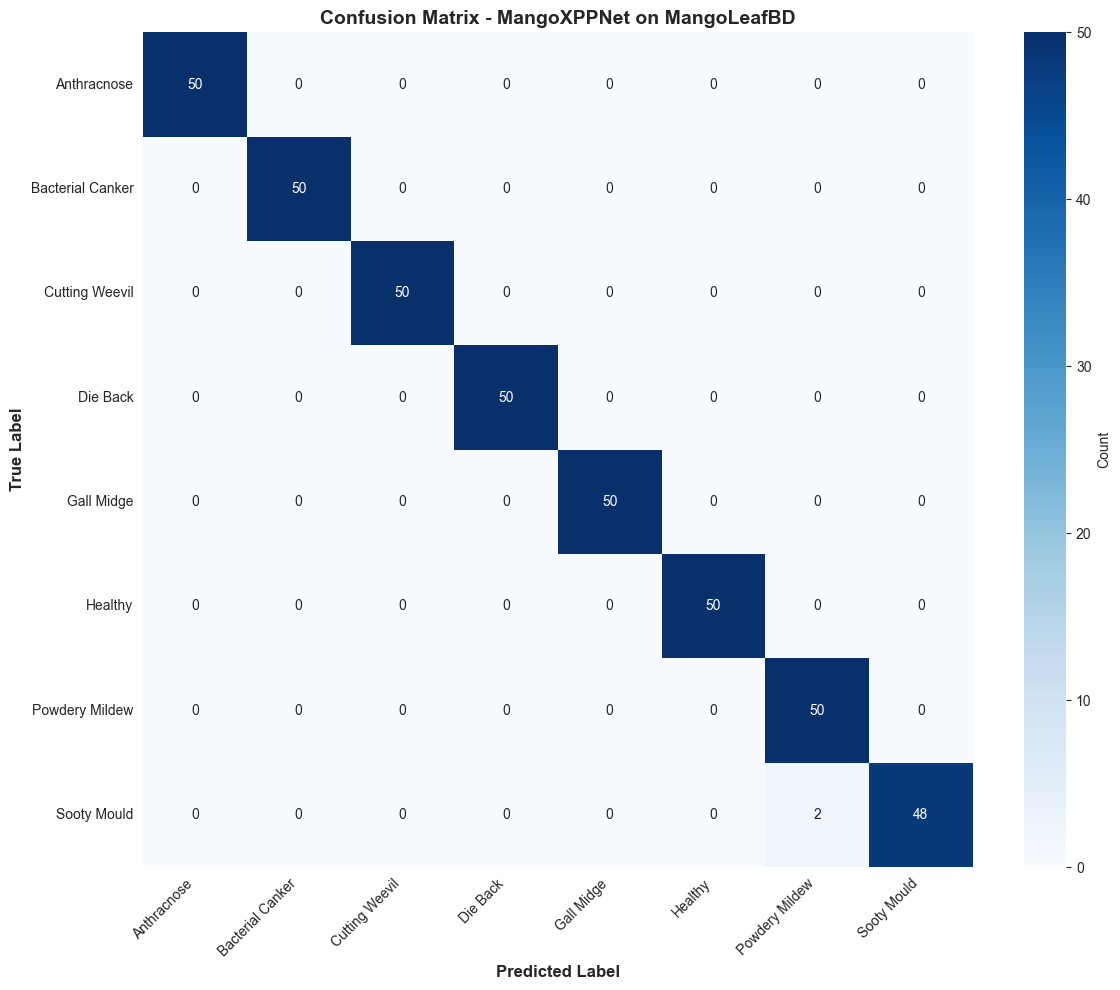

✅ Confusion matrix saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/MangoXPPNet/run_8/confusion_matrix.png


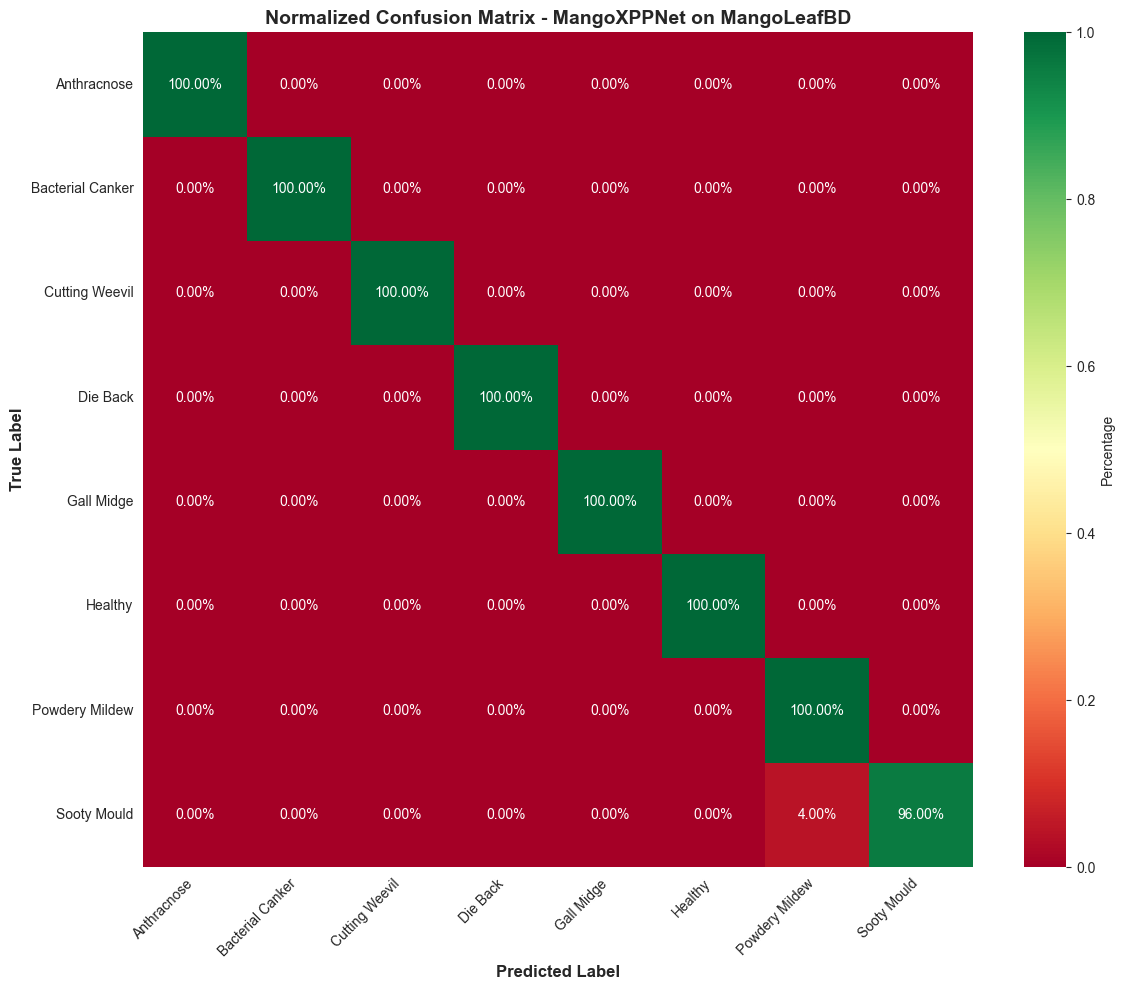

✅ Normalized confusion matrix saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/MangoXPPNet/run_8/confusion_matrix_normalized.png


In [20]:
# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=idx2name,
            yticklabels=idx2name,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title(f'Confusion Matrix - MangoXPPNet on {DATASET_NAME}', 
         fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
# --- Save to new per-run output dir ---
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Confusion matrix saved to: {OUTPUT_DIR / 'confusion_matrix.png'}")

# Calculate and plot normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn',
            xticklabels=idx2name,
            yticklabels=idx2name,
            cbar_kws={'label': 'Percentage'})
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title(f'Normalized Confusion Matrix - MangoXPPNet on {DATASET_NAME}', 
         fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_normalized.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Normalized confusion matrix saved to: {OUTPUT_DIR / 'confusion_matrix_normalized.png'}")

### 6.3.1 ROC Curve & AUC Analysis

Generate Receiver Operating Characteristic (ROC) curves and calculate Area Under the Curve (AUC) scores for each class using One-vs-Rest approach.

📊 ROC CURVE & AUC ANALYSIS


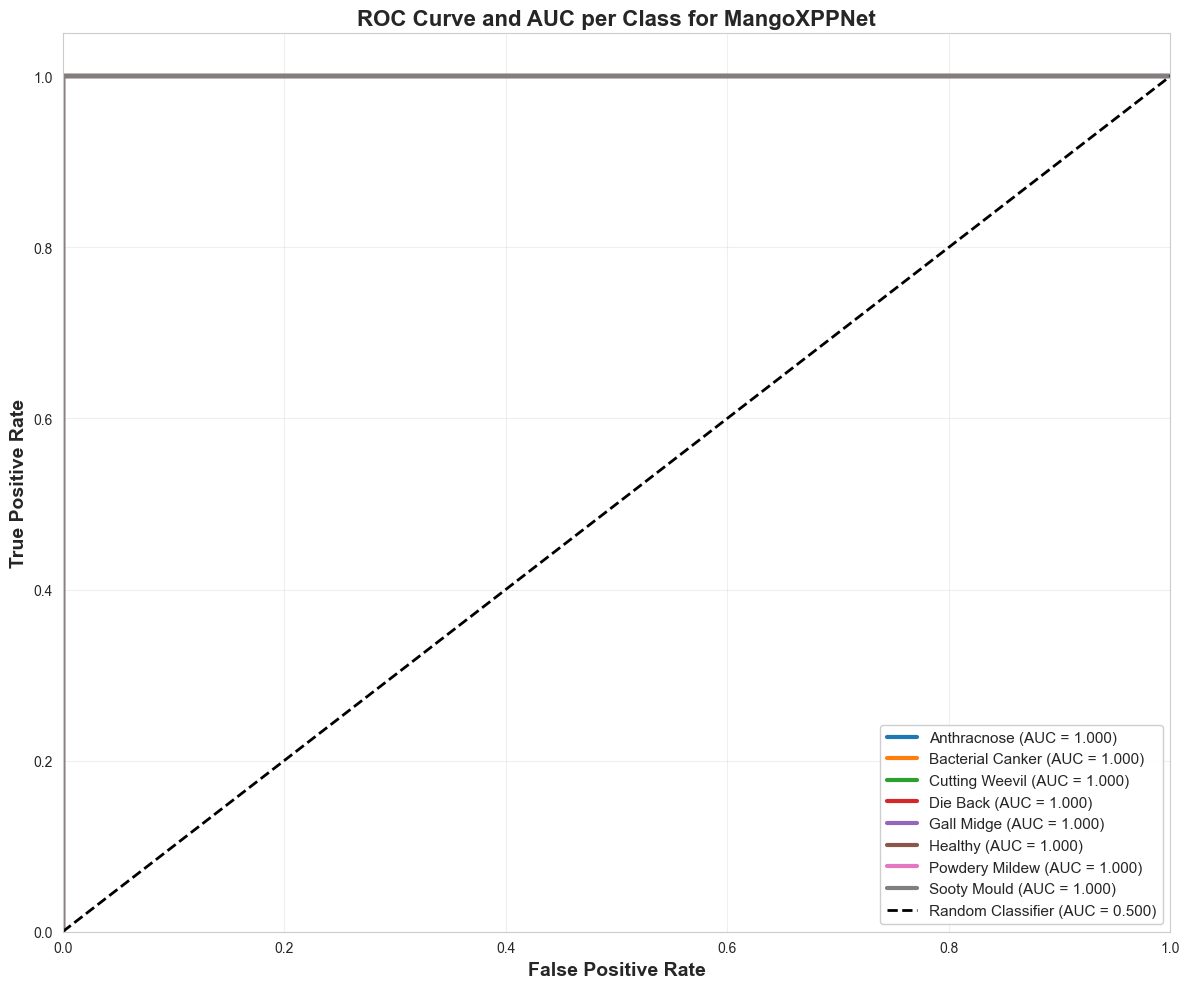

✅ Combined ROC curve saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/MangoXPPNet/run_8/roc_curve_combined.png


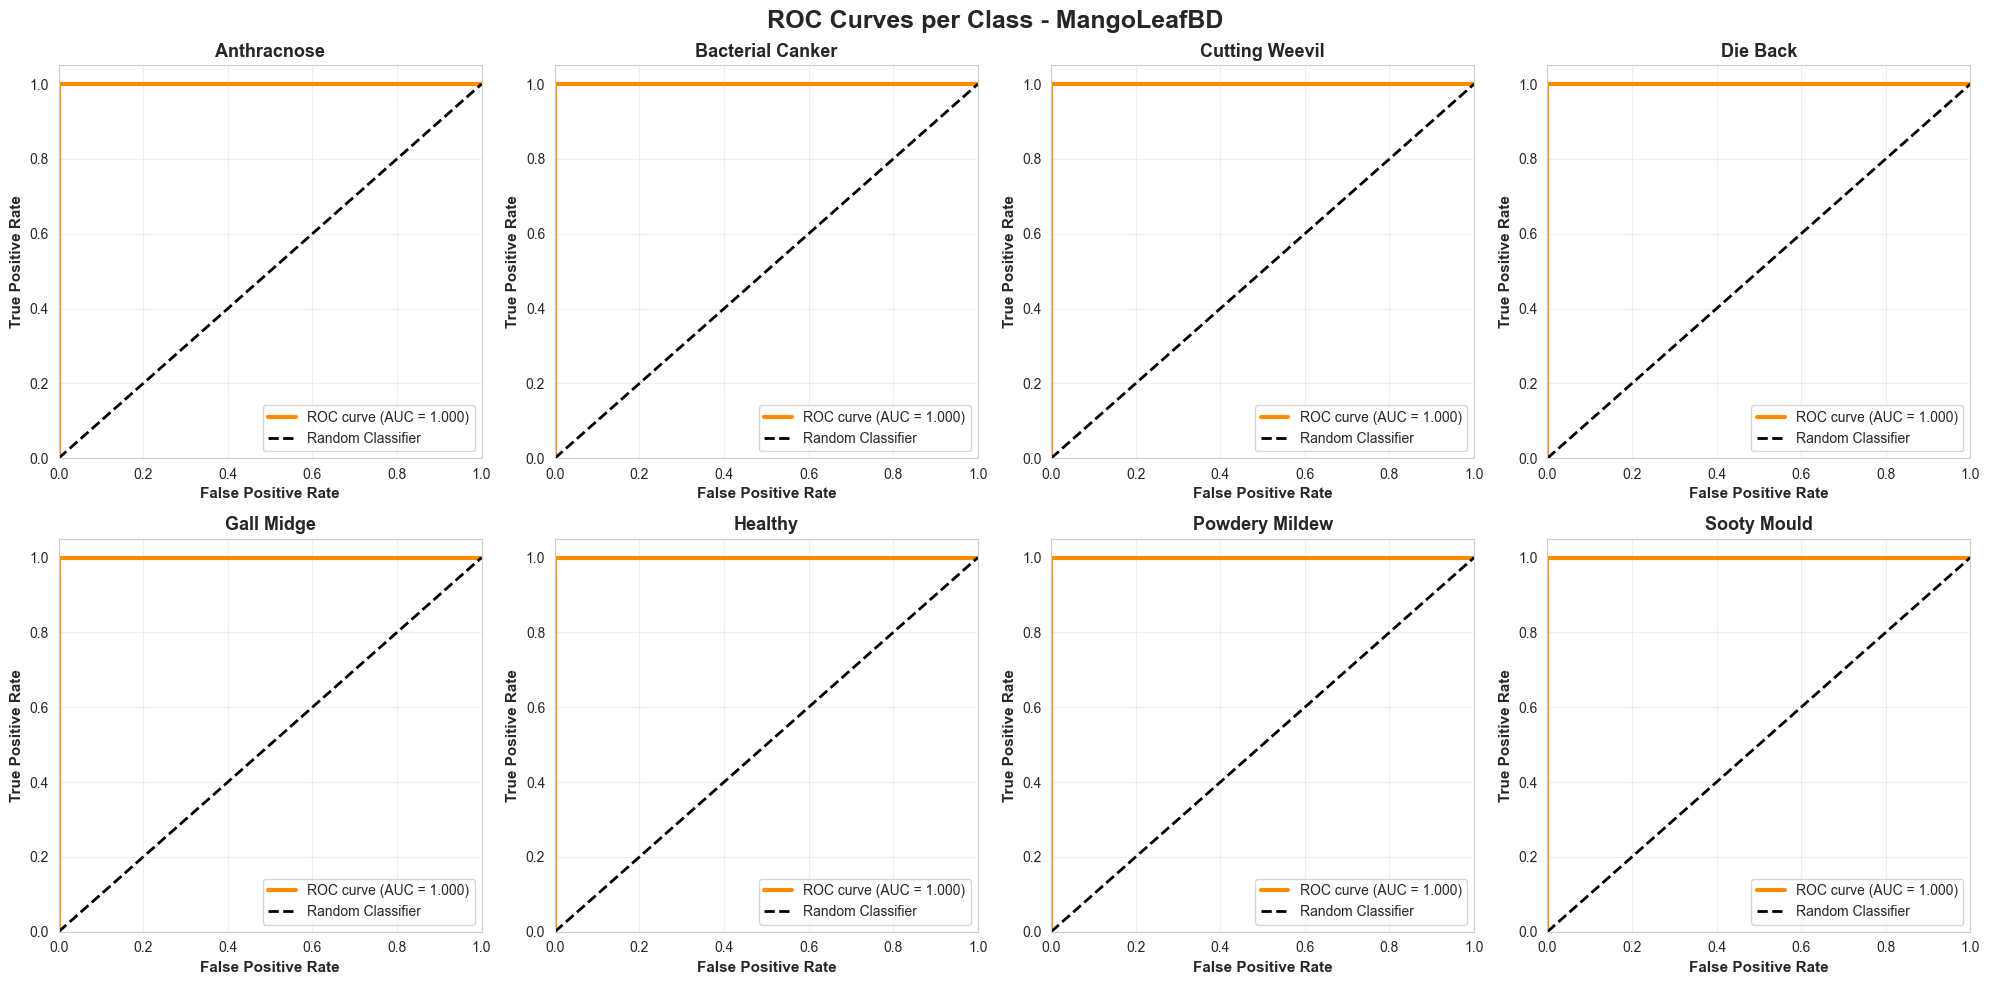

✅ Individual ROC curves saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/MangoXPPNet/run_8/roc_curves_individual.png

📊 AUC SCORES PER CLASS
           Class  AUC Score
     Anthracnose        1.0
Bacterial Canker        1.0
  Cutting Weevil        1.0
        Die Back        1.0
      Gall Midge        1.0
         Healthy        1.0
  Powdery Mildew        1.0
     Sooty Mould        1.0

--------------------------------------------------------------------------------
SUMMARY STATISTICS
--------------------------------------------------------------------------------
        Class  AUC Score
Micro-Average   0.999988
Macro-Average   1.000000
          Min   1.000000
          Max   1.000000

✅ AUC scores saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/MangoXPPNet/run_8/auc_scores.csv
✅ AUC summary saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/MangoXPPNet/run_8/auc_summary.csv

✅ ROC &

In [21]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# ============================================
# ROC Curve & AUC Analysis
# ============================================

print("=" * 80)
print("📊 ROC CURVE & AUC ANALYSIS")
print("=" * 80)

# Binarize the labels for One-vs-Rest approach
y_true_bin = label_binarize(y_true, classes=range(n_classes))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_pred_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# ============================================
# Plot 1: Combined ROC Curves for All Classes
# ============================================

plt.figure(figsize=(12, 10))

# Plot ROC curve for each class with thick lines
colors = cycle(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=3,
             label=f'{idx2name[i]} (AUC = {roc_auc[i]:.3f})')

# Plot diagonal (random classifier baseline)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.500)')

# Formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
plt.title('ROC Curve and AUC per Class for MangoXPPNet', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=11, framealpha=0.95)
plt.grid(alpha=0.3)
plt.tight_layout()

# Save combined ROC plot
plt.savefig(OUTPUT_DIR / 'roc_curve_combined.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Combined ROC curve saved to: {OUTPUT_DIR / 'roc_curve_combined.png'}")

# ============================================
# Plot 2: Individual ROC Curves (2x4 grid)
# ============================================

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i in range(n_classes):
    axes[i].plot(fpr[i], tpr[i], color='darkorange', lw=3,
                 label=f'ROC curve (AUC = {roc_auc[i]:.3f})')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
    axes[i].set_title(f'{idx2name[i]}', fontsize=13, fontweight='bold')
    axes[i].legend(loc="lower right", fontsize=10)
    axes[i].grid(alpha=0.3)

plt.suptitle(f'ROC Curves per Class - {DATASET_NAME}', fontsize=18, fontweight='bold')
plt.tight_layout()

# Save individual ROC plots
plt.savefig(OUTPUT_DIR / 'roc_curves_individual.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Individual ROC curves saved to: {OUTPUT_DIR / 'roc_curves_individual.png'}")

# ============================================
# AUC Scores Table
# ============================================

auc_df = pd.DataFrame({
    'Class': idx2name,
    'AUC Score': [roc_auc[i] for i in range(n_classes)]
})

# Add summary statistics
auc_summary = pd.DataFrame({
    'Class': ['Micro-Average', 'Macro-Average', 'Min', 'Max'],
    'AUC Score': [
        roc_auc["micro"],
        np.mean([roc_auc[i] for i in range(n_classes)]),
        np.min([roc_auc[i] for i in range(n_classes)]),
        np.max([roc_auc[i] for i in range(n_classes)])
    ]
})

print("\n" + "=" * 80)
print("📊 AUC SCORES PER CLASS")
print("=" * 80)
print(auc_df.to_string(index=False))
print("\n" + "-" * 80)
print("SUMMARY STATISTICS")
print("-" * 80)
print(auc_summary.to_string(index=False))
print("=" * 80)

# Save AUC scores
auc_df.to_csv(OUTPUT_DIR / 'auc_scores.csv', index=False)
print(f"\n✅ AUC scores saved to: {OUTPUT_DIR / 'auc_scores.csv'}")

# Save summary statistics
auc_summary.to_csv(OUTPUT_DIR / 'auc_summary.csv', index=False)
print(f"✅ AUC summary saved to: {OUTPUT_DIR / 'auc_summary.csv'}")

print("\n" + "=" * 80)
print("✅ ROC & AUC ANALYSIS COMPLETE")
print("=" * 80)

### 6.4 Performance Metrics Visualization

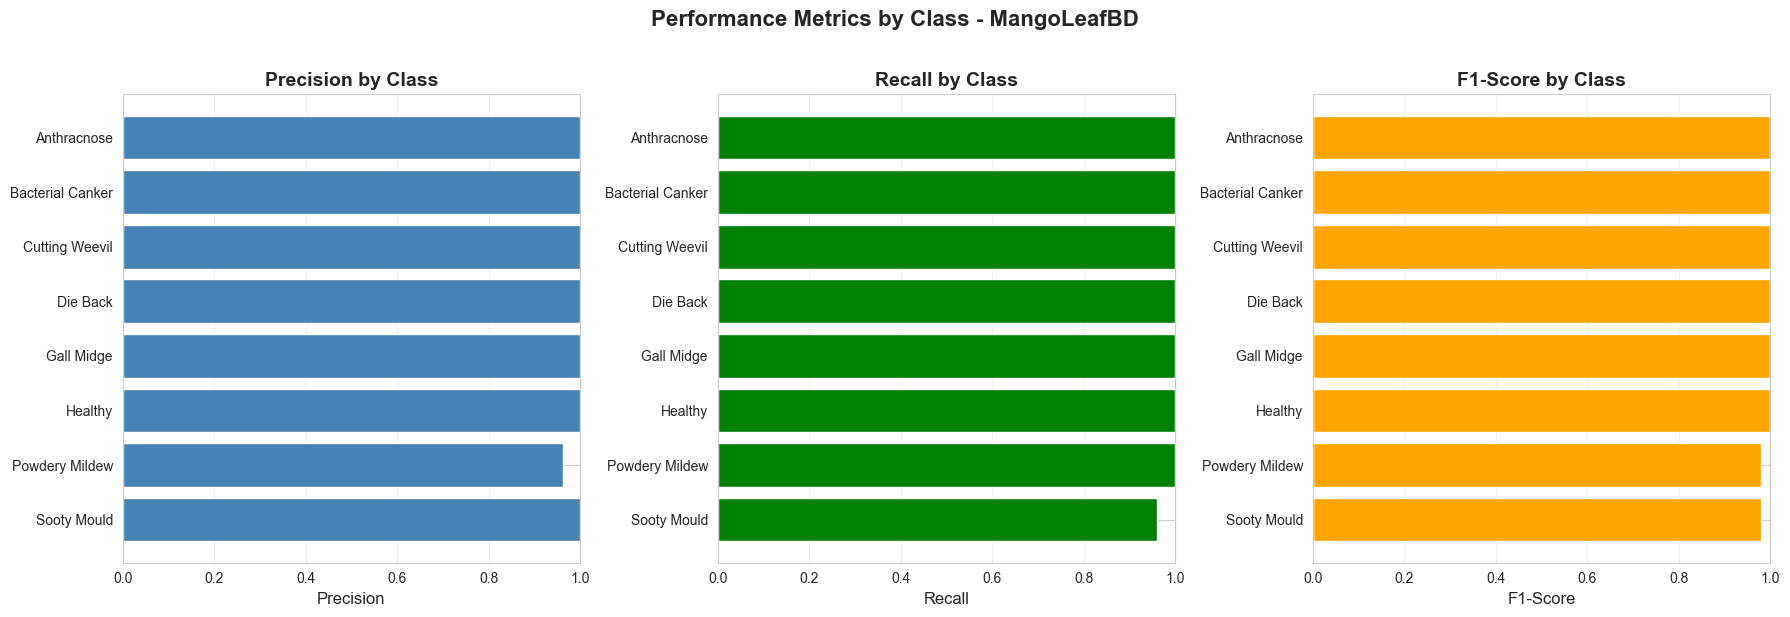

✅ Performance metrics visualization saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/MangoXPPNet/run_8/performance_metrics.png


In [22]:
# Plot per-class metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Precision
axes[0].barh(range(n_classes), metrics_df['Precision'], color='steelblue')
axes[0].set_yticks(range(n_classes))
axes[0].set_yticklabels(metrics_df['Class'])
axes[0].set_xlabel('Precision', fontsize=12)
axes[0].set_title('Precision by Class', fontsize=14, fontweight='bold')
axes[0].set_xlim([0, 1])
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Recall
axes[1].barh(range(n_classes), metrics_df['Recall'], color='green')
axes[1].set_yticks(range(n_classes))
axes[1].set_yticklabels(metrics_df['Class'])
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_title('Recall by Class', fontsize=14, fontweight='bold')
axes[1].set_xlim([0, 1])
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# F1-Score
axes[2].barh(range(n_classes), metrics_df['F1-Score'], color='orange')
axes[2].set_yticks(range(n_classes))
axes[2].set_yticklabels(metrics_df['Class'])
axes[2].set_xlabel('F1-Score', fontsize=12)
axes[2].set_title('F1-Score by Class', fontsize=14, fontweight='bold')
axes[2].set_xlim([0, 1])
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3)

plt.suptitle(f'Performance Metrics by Class - {DATASET_NAME}', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
# --- Save to new per-run output dir ---
plt.savefig(OUTPUT_DIR / 'performance_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Performance metrics visualization saved to: {OUTPUT_DIR / 'performance_metrics.png'}")

## 7. Prediction Examples

### 7.1 Visualize Correct and Incorrect Predictions

Total: 400 | Correct: 398 (99.5%) | Incorrect: 2


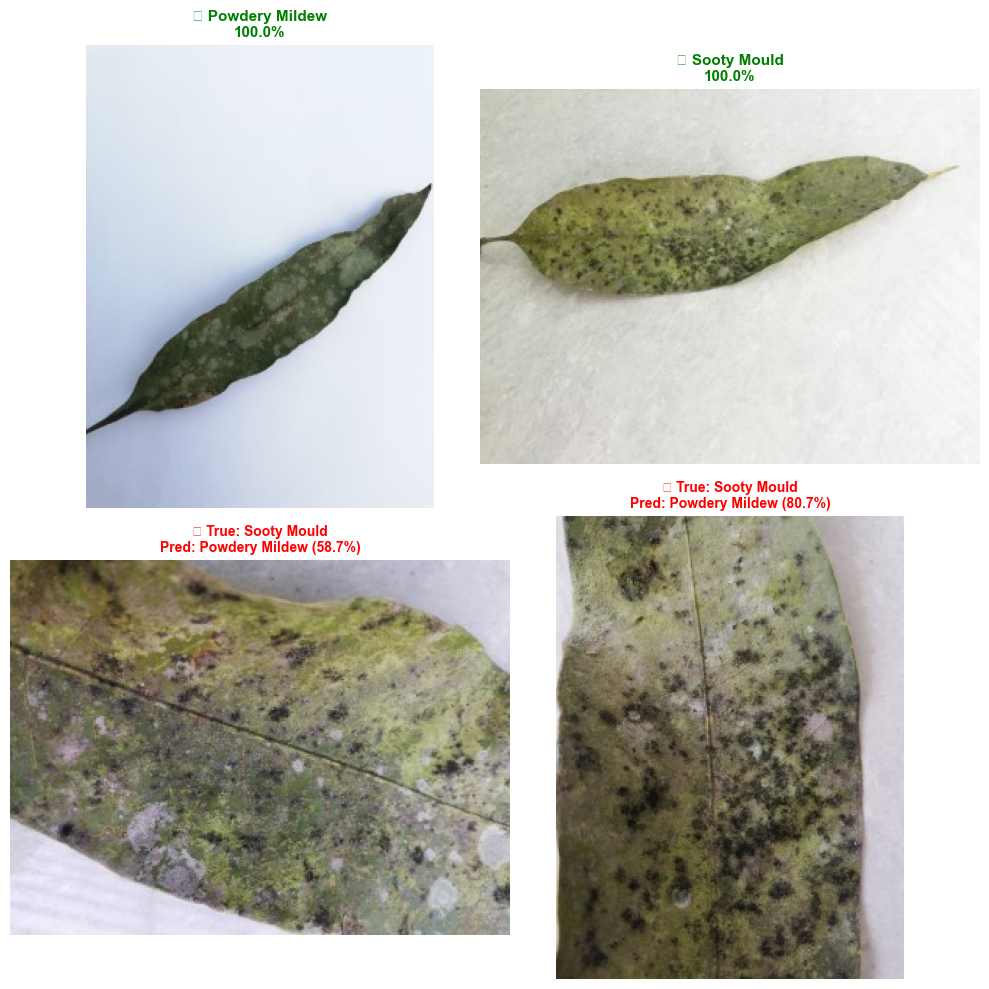

✅ Saved to /Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook/MangoLeafBD/outputs/MangoXPPNet/run_8/prediction_examples.png


In [ ]:
test_filenames = test_generator.filenames
correct_indices = np.where(y_pred == y_true)[0]
incorrect_indices = np.where(y_pred != y_true)[0]

print(f"Total: {len(y_true)} | Correct: {len(correct_indices)} ({len(correct_indices)/len(y_true)*100:.1f}%) | Incorrect: {len(incorrect_indices)}")

# Show 2 correct and 2 incorrect predictions
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

if len(correct_indices) >= 2:
    sample_correct = random.sample(list(correct_indices), 2)
    for i, idx in enumerate(sample_correct):
        img = Image.open(TEST_DIR / test_filenames[idx])
        pred_label = idx2name[y_pred[idx]]
        conf = y_pred_probs[idx][y_pred[idx]]
        
        axes[0, i].imshow(img)
        axes[0, i].set_title(f'✓ {pred_label}\n{conf:.1%}', fontsize=11, color='green', fontweight='bold')
        axes[0, i].axis('off')

if len(incorrect_indices) >= 2:
    sample_incorrect = random.sample(list(incorrect_indices), 2)
    for i, idx in enumerate(sample_incorrect):
        img = Image.open(TEST_DIR / test_filenames[idx])
        true_label = idx2name[y_true[idx]]
        pred_label = idx2name[y_pred[idx]]
        conf = y_pred_probs[idx][y_pred[idx]]
        
        axes[1, i].imshow(img)
        axes[1, i].set_title(f'✗ True: {true_label}\nPred: {pred_label} ({conf:.1%})', 
                           fontsize=10, color='red', fontweight='bold')
        axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'prediction_examples.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved to {OUTPUT_DIR / 'prediction_examples.png'}")

## 8. Final Summary & Results

### 8.1 Complete Evaluation Summary

In [ ]:
# Calculate overall metrics
overall_accuracy = accuracy_score(y_true, y_pred)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)

# Create summary
summary = f"""
{'='*80}
                    MangoXPPNet - FINAL EVALUATION SUMMARY
{'='*80}

DATASET INFORMATION:
  • Dataset Name          : {DATASET_NAME}
  • Number of Classes     : {n_classes}
  • Classes               : {', '.join(idx2name)}
  • Training Samples      : {train_generator.samples}
  • Validation Samples    : {val_generator.samples}
  • Test Samples          : {test_generator.samples}

MODEL ARCHITECTURE:
  • Architecture          : MangoXPPNet
  • Input Size            : {INPUT_HEIGHT}x{INPUT_WIDTH}x3
  • Total Parameters      : {total_params:,}
  • Trainable Parameters  : {trainable_params:,}

TRAINING CONFIGURATION:
  • Optimizer             : SGD (Nesterov Momentum)
  • Learning Rate         : {LEARNING_RATE}
  • Batch Size            : {BATCH_SIZE}
  • Epochs Trained        : {len(history.history['loss'])}
  • Training Time         : {training_time/60:.2f} minutes
  • Dropout Rate          : {DROPOUT_RATE}

PREPROCESSING:
  • Type                  : {'CLAHE + Normalization' if 'BD' in DATASET_NAME else 'Basic Normalization'}
  • Augmentation          : Rotation, Shift, Zoom, Flip, Brightness

TEST SET PERFORMANCE:
  • Overall Accuracy      : {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)
  
  Macro Average:
    - Precision           : {macro_precision:.4f}
    - Recall              : {macro_recall:.4f}
    - F1-Score            : {macro_f1:.4f}
  
  Weighted Average:
    - Precision           : {weighted_precision:.4f}
    - Recall              : {weighted_recall:.4f}
    - F1-Score            : {weighted_f1:.4f}

BEST EPOCH METRICS (Validation):
  • Best Epoch            : {best_epoch + 1}/{EPOCHS}
  • Training Loss         : {history.history['loss'][best_epoch]:.4f}
  • Training Accuracy     : {history.history['accuracy'][best_epoch]:.4f}
  • Validation Loss       : {history.history['val_loss'][best_epoch]:.4f}
  • Validation Accuracy   : {history.history['val_accuracy'][best_epoch]:.4f}

OUTPUT FILES:
  • Model                 : {model_path}
  • Classes JSON          : {EXPERIMENT_DIR / 'classes.json'}
  • Training History      : {EXPERIMENT_DIR / 'history.json'}
  • Model Info            : {EXPERIMENT_DIR / 'model_info.json'}
  • Classification Report : {OUTPUT_DIR / 'classification_report.txt'}
  • Confusion Matrix      : {OUTPUT_DIR / 'confusion_matrix.png'}
  • Metrics CSV           : {OUTPUT_DIR / 'per_class_metrics.csv'}

{'='*80}
"""

print(summary)

# Save summary to file
with open(OUTPUT_DIR / 'evaluation_summary.txt', 'w') as f:
    f.write(summary)

print(f"\n✅ Evaluation summary saved to: {OUTPUT_DIR / 'evaluation_summary.txt'}")

### 8.2 Inference Function for New Images

In [ ]:
def predict_single_image(image_path, model, class_names, preprocessing_fn, 
                        input_size=(227, 227), show_plot=True):
    """
    Predict class for a single image
    
    Args:
        image_path: Path to the image file
        model: Trained model
        class_names: List of class names in order
        preprocessing_fn: Preprocessing function
        input_size: Input size for the model (width, height)
        show_plot: Whether to display the image with prediction
    
    Returns:
        Dictionary with prediction results
    """
    # Load and preprocess image
    img = Image.open(image_path)
    img_resized = img.resize(input_size)
    img_array = np.array(img_resized)
    
    # Apply preprocessing
    img_preprocessed = preprocessing_fn(img_array)
    img_batch = np.expand_dims(img_preprocessed, axis=0)
    
    # Make prediction
    predictions = model.predict(img_batch, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    predicted_class = class_names[predicted_class_idx]
    confidence = predictions[0][predicted_class_idx] * 100
    
    # Get top 3 predictions
    top_3_indices = np.argsort(predictions[0])[-3:][::-1]
    top_3_predictions = [(class_names[i], predictions[0][i] * 100) for i in top_3_indices]
    
    # Display results
    if show_plot:
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'Predicted: {predicted_class} ({confidence:.2f}% confidence)', 
                 fontsize=14, fontweight='bold', color='green' if confidence > 80 else 'orange')
        
        # Add top 3 predictions text
        text = "Top 3 Predictions:\n"
        for i, (cls, conf) in enumerate(top_3_predictions, 1):
            text += f"{i}. {cls}: {conf:.2f}%\n"
        
        plt.text(10, img.size[1] - 10, text, fontsize=10, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='bottom')
        plt.tight_layout()
        plt.show()
    
    result = {
        'predicted_class': predicted_class,
        'confidence': confidence,
        'all_predictions': {class_names[i]: predictions[0][i] * 100 for i in range(len(class_names))},
        'top_3': top_3_predictions
    }
    
    return result

print("✅ Inference function defined!")
print("\nUsage example:")
print("  result = predict_single_image(")
print("      'path/to/image.jpg',")
print("      model=best_model,")
print("      class_names=idx2name,")
print("      preprocessing_fn=preprocessing_fn")
print("  )")

### 8.3 Test Inference on Sample Images

In [ ]:
# Test inference on random test images
print("Testing inference on sample test images...\n")

# Get 3 random test images
test_image_paths = []
for class_dir in TEST_DIR.iterdir():
    if class_dir.is_dir():
        imgs = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png'))
        if imgs:
            test_image_paths.append(random.choice(imgs))

# Limit to 3 samples
test_image_paths = random.sample(test_image_paths, min(3, len(test_image_paths)))

for i, img_path in enumerate(test_image_paths, 1):
    print(f"\n{'='*60}")
    print(f"Sample {i}: {img_path.name}")
    print(f"True class (from folder): {img_path.parent.name}")
    print('='*60)
    
    result = predict_single_image(
        img_path,
        model=best_model,
        class_names=idx2name,
        preprocessing_fn=preprocessing_fn,
        show_plot=True
    )
    
    print(f"\nPredicted: {result['predicted_class']}")
    print(f"Confidence: {result['confidence']:.2f}%")
    print("\nAll class probabilities:")
    for cls, prob in sorted(result['all_predictions'].items(), key=lambda x: x[1], reverse=True):
        print(f"  {cls:20s}: {prob:6.2f}%")

## 9. Explainable AI (XAI) Analysis

### 9.1 Setup XAI Environment

In [23]:
# ============================================
# XAI SETUP AND DIRECTORY CONFIGURATION
# ============================================

# Create XAI output directories
XAI_DIR = OUTPUT_DIR / 'XAI'
GRADCAM_DIR = XAI_DIR / 'Grad-CAM'
SALIENCY_DIR = XAI_DIR / 'Saliency'
LIME_DIR = XAI_DIR / 'LIME'

# Create directories
for dir_path in [XAI_DIR, GRADCAM_DIR, SALIENCY_DIR, LIME_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("📁 XAI OUTPUT DIRECTORIES")
print("=" * 60)
print(f"XAI Base Dir  : {XAI_DIR}")
print(f"Grad-CAM Dir  : {GRADCAM_DIR}")
print(f"Saliency Dir  : {SALIENCY_DIR}")
print(f"LIME Dir      : {LIME_DIR}")
print("=" * 60)

# Install LIME if not available (uncomment if needed)
#!pip install lime

# Try to import LIME
try:
    from lime import lime_image
    from skimage.segmentation import mark_boundaries
    LIME_AVAILABLE = True
    print("\n✅ LIME library available")
except ImportError:
    LIME_AVAILABLE = False
    print("\n⚠️ LIME library not installed. Run: pip install lime")
    print("   LIME explanations will be skipped.")

📁 XAI OUTPUT DIRECTORIES
XAI Base Dir  : /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/MangoXPPNet/run_8/XAI
Grad-CAM Dir  : /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/MangoXPPNet/run_8/XAI/Grad-CAM
Saliency Dir  : /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/MangoXPPNet/run_8/XAI/Saliency
LIME Dir      : /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/MangoXPPNet/run_8/XAI/LIME

✅ LIME library available


### 9.2 Grad-CAM Implementation

In [24]:
def get_last_conv_layer_name(model):
    """Find the last convolutional layer in the model."""
    for layer in reversed(model.layers):
        if 'conv' in layer.name.lower() or isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("Could not find a convolutional layer in the model")


def get_all_conv_layers(model):
    """Get a selection of convolutional layers for multi-layer visualization."""
    conv_layers = []
    for layer in model.layers:
        if 'conv' in layer.name.lower() or isinstance(layer, tf.keras.layers.Conv2D):
            conv_layers.append(layer.name)
    
    if not conv_layers:
        raise ValueError("Could not find any convolutional layers in the model")
    
    num_layers = len(conv_layers)
    if num_layers <= 4:
        return conv_layers
    elif num_layers <= 8:
        indices = [0, num_layers // 2, num_layers - 1]
        return [conv_layers[i] for i in indices]
    else:
        step = num_layers // 5
        indices = [i * step for i in range(5)] + [num_layers - 1]
        return [conv_layers[i] for i in sorted(set(indices))]


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generate Grad-CAM heatmap for a given image and model layer.
    
    Args:
        img_array: Preprocessed image array (batch format)
        model: Trained Keras model
        last_conv_layer_name: Name of the convolutional layer to use
        pred_index: Index of the predicted class (optional)
    
    Returns:
        Normalized heatmap as numpy array
    """
    # Create gradient model
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    # Compute gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    
    grads = tape.gradient(class_channel, conv_outputs)
    
    # Handle case where gradients might be None
    if grads is None:
        return np.zeros((INPUT_HEIGHT, INPUT_WIDTH))
    
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normalize with protection against division by zero
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.math.reduce_max(heatmap)
    if max_val > 0:
        heatmap = heatmap / max_val
    
    return heatmap.numpy()


def create_multilayer_gradcam(img_path, model, class_names, preprocessing_fn=None, alpha=0.4):
    """
    Create Grad-CAM visualizations for multiple convolutional layers.
    
    Args:
        img_path: Path to the input image
        model: Trained Keras model
        class_names: List of class names
        preprocessing_fn: Optional preprocessing function
        alpha: Overlay transparency
    
    Returns:
        Dictionary mapping layer names to (original, heatmap, superimposed, class, confidence) tuples
    """
    conv_layers = get_all_conv_layers(model)
    
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(INPUT_HEIGHT, INPUT_WIDTH))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    original_img = img_array.copy()
    
    if preprocessing_fn:
        img_array_processed = preprocessing_fn(img_array.copy())
    else:
        img_array_processed = img_array.copy()
    
    img_batch = np.expand_dims(img_array_processed, axis=0)
    
    preds = model.predict(img_batch, verbose=0)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx] * 100  # Convert to percentage
    predicted_class = class_names[pred_idx]
    
    results = {}
    for layer_name in conv_layers:
        try:
            heatmap = make_gradcam_heatmap(img_batch, model, layer_name, pred_idx)
            heatmap_resized = cv2.resize(heatmap, (INPUT_WIDTH, INPUT_HEIGHT))
            heatmap_colored = plt.cm.jet(heatmap_resized)[:, :, :3] * 255
            superimposed = (original_img * (1 - alpha) + heatmap_colored * alpha).astype(np.uint8)
            results[layer_name] = (original_img, heatmap_resized, superimposed, predicted_class, confidence)
        except Exception as e:
            print(f"  Warning: Could not generate Grad-CAM for layer {layer_name}: {e}")
            continue
    
    return results


def create_gradcam_visualization(img_path, model, last_conv_layer_name, class_names, preprocessing_fn=None, alpha=0.4):
    """
    Create a single Grad-CAM visualization for a specific layer.
    
    Args:
        img_path: Path to the input image
        model: Trained Keras model
        last_conv_layer_name: Name of the convolutional layer
        class_names: List of class names
        preprocessing_fn: Optional preprocessing function
        alpha: Overlay transparency
    
    Returns:
        Tuple of (original_img, heatmap, superimposed, predicted_class, confidence)
    """
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(INPUT_HEIGHT, INPUT_WIDTH))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    original_img = img_array.copy()
    
    if preprocessing_fn:
        img_array = preprocessing_fn(img_array)
    
    img_array = np.expand_dims(img_array, axis=0)
    preds = model.predict(img_array, verbose=0)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx] * 100  # Convert to percentage
    predicted_class = class_names[pred_idx]
    
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_idx)
    heatmap_resized = cv2.resize(heatmap, (INPUT_WIDTH, INPUT_HEIGHT))
    heatmap_colored = plt.cm.jet(heatmap_resized)[:, :, :3] * 255
    superimposed = (original_img * (1 - alpha) + heatmap_colored * alpha).astype(np.uint8)
    
    return original_img, heatmap_resized, superimposed, predicted_class, confidence

print("✅ Grad-CAM functions defined successfully")

✅ Grad-CAM functions defined successfully


### 9.3 Saliency Maps Implementation

**Saliency Maps** show the gradient of the output with respect to the input image. They highlight which pixels need to change the least to affect the class score the most.

In [25]:
def compute_saliency_map(img_path, model, class_names, preprocess_fn=None):
    """
    Compute saliency map for an input image.
    
    Args:
        img_path: Path to the input image
        model: Trained Keras model
        class_names: List of class names
        preprocess_fn: Optional preprocessing function
    
    Returns:
        original_img: Original image as uint8
        saliency: Normalized saliency map
        pred_class: Predicted class name
        confidence: Prediction confidence
    """
    # Load image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(INPUT_HEIGHT, INPUT_WIDTH))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    original_img = img_array.copy().astype(np.uint8)
    
    # Preprocess for model
    if preprocess_fn is not None:
        img_processed = preprocess_fn(img_array.copy())
    else:
        img_processed = img_array.copy()
    
    img_batch = np.expand_dims(img_processed, axis=0)
    
    # Convert to tensor for gradient computation
    img_tensor = tf.Variable(img_batch, dtype=tf.float32)
    
    # Compute gradients
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        predictions = model(img_tensor, training=False)
        top_class = tf.argmax(predictions[0])
        top_score = predictions[0, top_class]
    
    # Get gradients
    grads = tape.gradient(top_score, img_tensor)
    
    # Compute saliency: take absolute value and max across color channels
    saliency = tf.abs(grads)
    saliency = tf.reduce_max(saliency, axis=-1)[0]  # [H, W]
    
    # Normalize to [0, 1]
    saliency = saliency.numpy()
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    
    # Get prediction info
    pred_class = class_names[top_class.numpy()]
    confidence = float(top_score.numpy())
    
    return original_img, saliency, pred_class, confidence

print("✅ Saliency map function defined")

✅ Saliency map function defined


### 9.4 LIME Implementation

**LIME (Local Interpretable Model-Agnostic Explanations)** explains predictions by approximating the model locally with an interpretable model. It perturbs the input and observes how predictions change to determine feature importance.

In [148]:
if LIME_AVAILABLE:
    def generate_lime_explanation(img_path, model, class_names, preprocess_fn, num_samples=1500):
        # Load image
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(INPUT_HEIGHT, INPUT_WIDTH))
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        original_img = img_array.copy().astype(np.uint8)
        
        # Get prediction
        img_processed = preprocess_fn(img_array.copy())
        img_processed = np.expand_dims(img_processed, axis=0)
        
        predictions = model.predict(img_processed, verbose=0)
        pred_class_idx = np.argmax(predictions[0])
        pred_class = class_names[pred_class_idx]
        confidence = float(predictions[0][pred_class_idx])
        
        # Define prediction function for LIME
        def predict_fn(images):
            processed = np.array([preprocess_fn(img.copy()) for img in images])
            return model.predict(processed, verbose=0)
        
        # Create LIME explainer
        explainer = lime_image.LimeImageExplainer()
        
        # Generate explanation
        explanation = explainer.explain_instance(
            img_array.astype(np.float64),
            predict_fn,
            top_labels=1,
            hide_color=0,
            num_samples=num_samples,
            batch_size=32
        )
        
        # Get mask for positive regions (important for prediction)
        temp, mask = explanation.get_image_and_mask(
            pred_class_idx,
            positive_only=True,
            num_features=10,
            hide_rest=False,
            min_weight=0.1
        )
        
        # --- CREATE SOLID FILLED OVERLAY (Matching Figure 31) ---
        # Start with original image
        lime_overlay = original_img.copy().astype(np.float32)
        
        # Define the solid red/orange fill color (RGB)
        # This matches the example image with red/orange highlight
        fill_color = np.array([255, 100, 50], dtype=np.float32)  # Red-orange color
        
        # Create 3D mask for blending
        mask_3d = np.stack([mask] * 3, axis=-1).astype(bool)
        
        # Apply SOLID color fill where mask is True (alpha blending)
        alpha = 0.6  # Transparency - higher means more color visible
        lime_overlay = np.where(
            mask_3d,
            lime_overlay * (1 - alpha) + fill_color * alpha,
            lime_overlay
        )
        lime_overlay = np.clip(lime_overlay, 0, 255).astype(np.uint8)
        
        # Add yellow boundary lines around the important regions
        lime_overlay_with_boundary = mark_boundaries(
            lime_overlay / 255.0, 
            mask, 
            color=(1, 1, 0),  # Yellow boundary
            mode='thick'
        )
        lime_overlay_with_boundary = (lime_overlay_with_boundary * 255).astype(np.uint8)
        
        return original_img, lime_overlay_with_boundary, mask, explanation, pred_class, confidence
    
    print("✅ LIME explanation function defined (with SOLID filled overlay)")
else:
    print("⚠️ LIME not available - skipping LIME implementation")

✅ LIME explanation function defined (with SOLID filled overlay)


### 9.5 Select Sample Images for XAI Analysis

We'll select representative images from each class for comprehensive XAI analysis.

In [30]:
# ============================================
# SELECT SAMPLE IMAGES FOR XAI ANALYSIS
# ============================================

# Get one representative image from each class
xai_sample_images = {}
print("=" * 60)
print("📷 SELECTING SAMPLE IMAGES FOR XAI ANALYSIS")
print("=" * 60)

for class_dir in sorted(TEST_DIR.iterdir()):
    if class_dir.is_dir():
        class_name = class_dir.name
        # Get all images in the class directory
        images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpeg'))
        if images:
            # Select a random image from this class
            selected_img = random.choice(images)
            xai_sample_images[class_name] = selected_img
            print(f"  ✅ {class_name:20s}: {selected_img.name}")

print(f"\n📊 Total samples selected: {len(xai_sample_images)}")
print("=" * 60)

📷 SELECTING SAMPLE IMAGES FOR XAI ANALYSIS
  ✅ Anthracnose         : 20211008_124310 (Custom).jpg
  ✅ Bacterial Canker    : IMG_20211106_120857 (Custom).jpg
  ✅ Cutting Weevil      : 20211011_162433(0) (Custom) (Custom).jpg
  ✅ Die Back            : IMG_20211027_183316 (Custom).jpg
  ✅ Gall Midge          : IMG_20211106_164757 (Custom).jpg
  ✅ Healthy             : 20211231_160003 (Custom).jpg
  ✅ Powdery Mildew      : 20211109_122343 (Custom).jpg
  ✅ Sooty Mould         : IMG_20211108_120232 (Custom).jpg

📊 Total samples selected: 8


### 9.6 Generate Grad-CAM Visualizations

Generate and save Grad-CAM visualizations for all sample images.

In [28]:
import gc

print("=" * 80)
print("🔥 GENERATING MULTI-LAYER GRAD-CAM VISUALIZATIONS")
print("=" * 80)

conv_layers = get_all_conv_layers(best_model)
print(f"\nFound {len(conv_layers)} convolutional layers for analysis")

MULTILAYER_DIR = GRADCAM_DIR / 'MultiLayer'
MULTILAYER_DIR.mkdir(exist_ok=True)

print("\nGenerating layer-wise Grad-CAM progression for each class...\n")

for class_name, img_path in sorted(xai_sample_images.items()):
    print(f"Processing: {class_name}")
    
    try:
        multilayer_results = create_multilayer_gradcam(
            img_path, best_model, idx2name, preprocessing_fn
        )
        
        if not multilayer_results:
            print(f"  ⚠️ No results for {class_name}")
            continue
        
        first_result = list(multilayer_results.values())[0]
        _, _, _, pred_class, confidence = first_result
        
        num_layers = len(multilayer_results)
        fig, axes = plt.subplots(3, num_layers, figsize=(4 * num_layers, 12))
        
        if num_layers == 1:
            axes = axes.reshape(3, 1)
        
        for col, (layer_name, (original, heatmap, superimposed, _, _)) in enumerate(multilayer_results.items()):
            axes[0, col].imshow(original.astype(np.uint8))
            axes[0, col].set_title(f'Original - {class_name}' if col == 0 else 'Original', fontsize=11)
            axes[0, col].axis('off')
            
            axes[1, col].imshow(heatmap, cmap='jet')
            axes[1, col].set_title(f'{layer_name}', fontsize=10)
            axes[1, col].axis('off')
            
            axes[2, col].imshow(superimposed)
            axes[2, col].set_title(f'Pred: {pred_class} ({confidence:.1f}%)', fontsize=10)
            axes[2, col].axis('off')
        
        fig.suptitle(f'Multi-Layer Grad-CAM: {class_name}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        
        save_path = MULTILAYER_DIR / f'GradCAM_MultiLayer_{class_name}.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        plt.close()
        
        print(f"  ✅ Saved: {save_path.name}")
        
        # Clear memory after each image
        gc.collect()
        
    except Exception as e:
        print(f"  ❌ Error processing {class_name}: {e}")
        plt.close('all')
        gc.collect()

print("\n" + "=" * 80)
print("GRAD-CAM GENERATION COMPLETE")
print("=" * 80)

🔥 GENERATING MULTI-LAYER GRAD-CAM VISUALIZATIONS

Found 6 convolutional layers for analysis

Generating layer-wise Grad-CAM progression for each class...



NameError: name 'xai_sample_images' is not defined

### 9.7 Generate Saliency Maps

Generate and save Saliency Maps for all sample images.

In [31]:
import gc

print("=" * 80)
print("🔥 GENERATING SALIENCY MAPS")
print("=" * 80)

# Initialize results dictionary to store saliency results
saliency_results = {}

# Generate individual saliency maps for each class
for class_name, img_path in sorted(xai_sample_images.items()):
    print(f"Processing: {class_name}")
    
    try:
        original_img, saliency_map, pred_class, confidence = compute_saliency_map(
            str(img_path), best_model, idx2name, preprocessing_fn
        )
        
        # Store results for summary
        saliency_results[class_name] = {
            'predicted_class': pred_class,
            'confidence': confidence,
            'correct': pred_class == class_name,
            'image_path': str(img_path),
            'saliency_map': saliency_map,
            'original_img': original_img
        }
        
        # Create individual figure matching Figure 30 format (Original + Saliency side by side)
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        
        # Original image
        axes[0].imshow(original_img)
        axes[0].set_title(f'Original Image', fontsize=12)
        axes[0].axis('off')
        
        # Saliency map (heat map visualization)
        axes[1].imshow(saliency_map, cmap='hot')
        axes[1].set_title(f'Saliency Map', fontsize=12)
        axes[1].axis('off')
        
        plt.suptitle(f'{class_name}\nPredicted: {pred_class} ({confidence:.1%})', fontsize=14, fontweight='bold')
        plt.tight_layout()
        
        save_path = SALIENCY_DIR / f'Saliency_{class_name}.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        plt.close()
        
        print(f"  ✅ Saved: {save_path.name}")
        gc.collect()
        
    except Exception as e:
        print(f"  ❌ Error processing {class_name}: {e}")
        import traceback
        traceback.print_exc()
        saliency_results[class_name] = {
            'predicted_class': 'Error',
            'confidence': 0.0,
            'correct': False,
            'image_path': str(img_path),
            'error': str(e)
        }
        plt.close('all')

# Create a combined figure like Figure 30 (grid of multiple classes)
print("\n📊 Creating combined saliency map figure...")
valid_results = {k: v for k, v in saliency_results.items() if 'error' not in v}

if valid_results:
    num_classes = len(valid_results)
    # Create grid: 2 columns per class (original + saliency), arrange in rows
    num_cols = 4  # 2 classes per row (each class has 2 images)
    num_rows = (num_classes + 1) // 2
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))
    if num_rows == 1:
        axes = axes.reshape(1, -1)
    
    for idx, (class_name, result) in enumerate(sorted(valid_results.items())):
        row = idx // 2
        col_base = (idx % 2) * 2
        
        # Original image
        axes[row, col_base].imshow(result['original_img'])
        axes[row, col_base].set_title(f'{class_name}\n(Original)', fontsize=10)
        axes[row, col_base].axis('off')
        
        # Saliency map
        axes[row, col_base + 1].imshow(result['saliency_map'], cmap='hot')
        axes[row, col_base + 1].set_title(f'{class_name}\n(Saliency)', fontsize=10)
        axes[row, col_base + 1].axis('off')
    
    # Hide unused subplots
    total_slots = num_rows * 2  # 2 classes per row
    for idx in range(num_classes, total_slots):
        row = idx // 2
        col_base = (idx % 2) * 2
        if row < num_rows:
            axes[row, col_base].axis('off')
            axes[row, col_base + 1].axis('off')
    
    plt.suptitle('Saliency Maps for Mango Leaf Conditions', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    combined_path = SALIENCY_DIR / 'Saliency_Combined_Figure30.png'
    plt.savefig(combined_path, dpi=200, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"  ✅ Combined figure saved: {combined_path.name}")

# Clean up stored arrays to free memory
for result in saliency_results.values():
    result.pop('saliency_map', None)
    result.pop('original_img', None)

print("\n" + "=" * 80)
print("SALIENCY MAP GENERATION COMPLETE")
print(f"Successfully processed: {sum(1 for r in saliency_results.values() if 'error' not in r)}/{len(saliency_results)} images")
print("=" * 80)

🔥 GENERATING SALIENCY MAPS
Processing: Anthracnose
  ✅ Saved: Saliency_Anthracnose.png
Processing: Bacterial Canker
  ✅ Saved: Saliency_Bacterial Canker.png
Processing: Cutting Weevil
  ✅ Saved: Saliency_Cutting Weevil.png
Processing: Die Back
  ✅ Saved: Saliency_Die Back.png
Processing: Gall Midge
  ✅ Saved: Saliency_Gall Midge.png
Processing: Healthy
  ✅ Saved: Saliency_Healthy.png
Processing: Powdery Mildew
  ✅ Saved: Saliency_Powdery Mildew.png
Processing: Sooty Mould
  ✅ Saved: Saliency_Sooty Mould.png

📊 Creating combined saliency map figure...
  ✅ Combined figure saved: Saliency_Combined_Figure30.png

SALIENCY MAP GENERATION COMPLETE
Successfully processed: 8/8 images


### 9.8 Generate LIME Explanations

Generate and save LIME (Local Interpretable Model-agnostic Explanations) for all sample images.

In [149]:
# Initialize LIME results dictionary
lime_results = {}

if LIME_AVAILABLE:
    print("=" * 80)
    print("🍋 GENERATING LIME EXPLANATIONS (with SOLID filled overlay)")
    print("=" * 80)
    
    for class_name, img_path in sorted(xai_sample_images.items()):
        print(f"Processing: {class_name}")
        
        try:
            original_img, lime_overlay, mask, explanation, pred_class, confidence = generate_lime_explanation(
                str(img_path), best_model, idx2name, preprocessing_fn
            )
            
            # Store results for summary
            lime_results[class_name] = {
                'predicted_class': pred_class,
                'confidence': confidence,
                'correct': pred_class == class_name,
                'image_path': str(img_path),
                'original_img': original_img,
                'lime_overlay': lime_overlay
            }
            
            # Create figure matching Figure 31 format
            # Shows Original + LIME overlay with solid red/orange filled regions
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            
            # Original image
            axes[0].imshow(original_img)
            axes[0].set_title('Original Image', fontsize=12)
            axes[0].axis('off')
            
            # LIME overlay - SOLID red/orange filled regions with yellow boundary
            axes[1].imshow(lime_overlay)
            axes[1].set_title('LIME Explanation', fontsize=12)
            axes[1].axis('off')
            
            plt.suptitle(f'{class_name}\nPredicted: {pred_class} ({confidence:.1%})', fontsize=14, fontweight='bold')
            plt.tight_layout()
            
            save_path = LIME_DIR / f'LIME_{class_name}.png'
            plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
            plt.close()
            
            print(f"  ✅ Saved: {save_path.name}")
            gc.collect()
            
        except Exception as e:
            print(f"  ❌ Error processing {class_name}: {e}")
            import traceback
            traceback.print_exc()
            lime_results[class_name] = {
                'predicted_class': 'Error',
                'confidence': 0.0,
                'correct': False,
                'image_path': str(img_path),
                'error': str(e)
            }
            plt.close('all')
    
    # Create combined LIME figure like Figure 31 (grid showing multiple classes)
    print("\n📊 Creating combined LIME figure...")
    valid_results = {k: v for k, v in lime_results.items() if 'error' not in v}
    
    if valid_results:
        num_classes = len(valid_results)
        # Each class gets 2 columns (original + LIME overlay)
        num_cols = 4  # 2 classes per row
        num_rows = (num_classes + 1) // 2
        
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))
        if num_rows == 1:
            axes = axes.reshape(1, -1)
        
        for idx, (class_name, result) in enumerate(sorted(valid_results.items())):
            row = idx // 2
            col_base = (idx % 2) * 2
            
            # Original image
            axes[row, col_base].imshow(result['original_img'])
            axes[row, col_base].set_title(f'{class_name}\n(Original)', fontsize=10)
            axes[row, col_base].axis('off')
            
            # LIME overlay with SOLID filled regions
            axes[row, col_base + 1].imshow(result['lime_overlay'])
            axes[row, col_base + 1].set_title(f'{class_name}\n(LIME)', fontsize=10)
            axes[row, col_base + 1].axis('off')
        
        # Hide unused subplots
        total_slots = num_rows * 2
        for idx in range(num_classes, total_slots):
            row = idx // 2
            col_base = (idx % 2) * 2
            if row < num_rows:
                axes[row, col_base].axis('off')
                axes[row, col_base + 1].axis('off')
        
        plt.suptitle('LIME Explanations - Solid Filled Overlay (Figure 31 Style)', fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        combined_path = LIME_DIR / 'LIME_Combined_Figure31.png'
        plt.savefig(combined_path, dpi=200, bbox_inches='tight', facecolor='white')
        plt.close()
        print(f"  ✅ Combined figure saved: {combined_path.name}")
    
    # Clean up stored arrays
    for result in lime_results.values():
        result.pop('original_img', None)
        result.pop('lime_overlay', None)
    
    print("\n" + "=" * 80)
    print("LIME GENERATION COMPLETE")
    print(f"Successfully processed: {sum(1 for r in lime_results.values() if 'error' not in r)}/{len(lime_results)} images")
    print("=" * 80)
else:
    print("⚠️ LIME not available - skipping LIME generation")
    # Create empty results for summary
    for class_name in xai_sample_images.keys():
        lime_results[class_name] = {
            'predicted_class': 'N/A',
            'confidence': 0.0,
            'correct': False,
            'image_path': str(xai_sample_images[class_name]),
            'error': 'LIME not available'
        }

🍋 GENERATING LIME EXPLANATIONS (with SOLID filled overlay)
Processing: Anthracnose


  0%|          | 0/1500 [00:00<?, ?it/s]

  ✅ Saved: LIME_Anthracnose.png
Processing: Bacterial Canker


  0%|          | 0/1500 [00:00<?, ?it/s]

  ✅ Saved: LIME_Bacterial Canker.png
Processing: Cutting Weevil


...

  ✅ Saved: LIME_Healthy.png
Processing: Powdery Mildew


  0%|          | 0/1500 [00:00<?, ?it/s]

  ✅ Saved: LIME_Powdery Mildew.png
Processing: Sooty Mould


  0%|          | 0/1500 [00:00<?, ?it/s]

  ✅ Saved: LIME_Sooty Mould.png

📊 Creating combined LIME figure...
  ✅ Combined figure saved: LIME_Combined_Figure31.png

LIME GENERATION COMPLETE
Successfully processed: 8/8 images


### 9.9 Display Generated XAI Visualizations

Display the generated Grad-CAM, Saliency Maps, and LIME explanation images for visual inspection.

In [ ]:
# DISPLAY GENERATED GRAD-CAM VISUALIZATIONS
# ============================================
from PIL import Image
import matplotlib.pyplot as plt

print("=" * 80)
print("📊 DISPLAYING GRAD-CAM VISUALIZATIONS")
print("=" * 80)

# Display combined Grad-CAM figure if exists
gradcam_combined = MULTILAYER_DIR / 'GradCAM_MultiLayer_combined.png'
if not gradcam_combined.exists():
    # Try to find any combined figure
    combined_files = list(GRADCAM_DIR.glob('**/*Combined*.png')) + list(GRADCAM_DIR.glob('**/*combined*.png'))
    if combined_files:
        gradcam_combined = combined_files[0]

# Display individual Grad-CAM images
gradcam_images = sorted(MULTILAYER_DIR.glob('*.png')) if MULTILAYER_DIR.exists() else []

if gradcam_images:
    print(f"\nFound {len(gradcam_images)} Grad-CAM images")
    
    # Display up to 4 images in a grid
    num_display = min(4, len(gradcam_images))
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for idx, img_path in enumerate(gradcam_images[:num_display]):
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(img_path.stem, fontsize=10)
        axes[idx].axis('off')
    
    # Hide unused axes
    for idx in range(num_display, 4):
        axes[idx].axis('off')
    
    plt.suptitle('Multi-Layer Grad-CAM Visualizations (Sample)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No Grad-CAM images found")

print("\n✅ Grad-CAM visualization display complete")

In [ ]:
# DISPLAY GENERATED SALIENCY MAP VISUALIZATIONS
# ============================================

print("=" * 80)
print("📊 DISPLAYING SALIENCY MAP VISUALIZATIONS")
print("=" * 80)

# Display individual Saliency images
saliency_images = sorted(SALIENCY_DIR.glob('Saliency_*.png')) if SALIENCY_DIR.exists() else []

# Filter out combined figures for individual display
individual_saliency = [img for img in saliency_images if 'Combined' not in img.name and 'combined' not in img.name]

if individual_saliency:
    print(f"\nFound {len(individual_saliency)} individual Saliency Map images")
    
    # Display all saliency maps in a grid
    num_images = len(individual_saliency)
    n_cols = min(3, num_images)
    n_rows = (num_images + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten() if num_images > 1 else [axes]
    
    for idx, img_path in enumerate(individual_saliency):
        img = Image.open(img_path)
        axes[idx].imshow(img)
        # Extract class name from filename
        class_name = img_path.stem.replace('Saliency_', '')
        axes[idx].set_title(class_name, fontsize=11, fontweight='bold')
        axes[idx].axis('off')
    
    # Hide unused axes
    for idx in range(num_images, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Saliency Maps for Mango Leaf Disease Classification', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Display combined saliency figure if exists
combined_saliency = list(SALIENCY_DIR.glob('*Combined*.png')) + list(SALIENCY_DIR.glob('*combined*.png'))
if combined_saliency:
    print(f"\n📄 Combined Saliency Figure:")
    fig, ax = plt.subplots(figsize=(16, 12))
    img = Image.open(combined_saliency[0])
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('Combined Saliency Maps (Figure 30 Style)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ No combined saliency figure found")

print("\n✅ Saliency Map visualization display complete")

📊 DISPLAYING LIME EXPLANATION VISUALIZATIONS

📄 Combined LIME Figure:


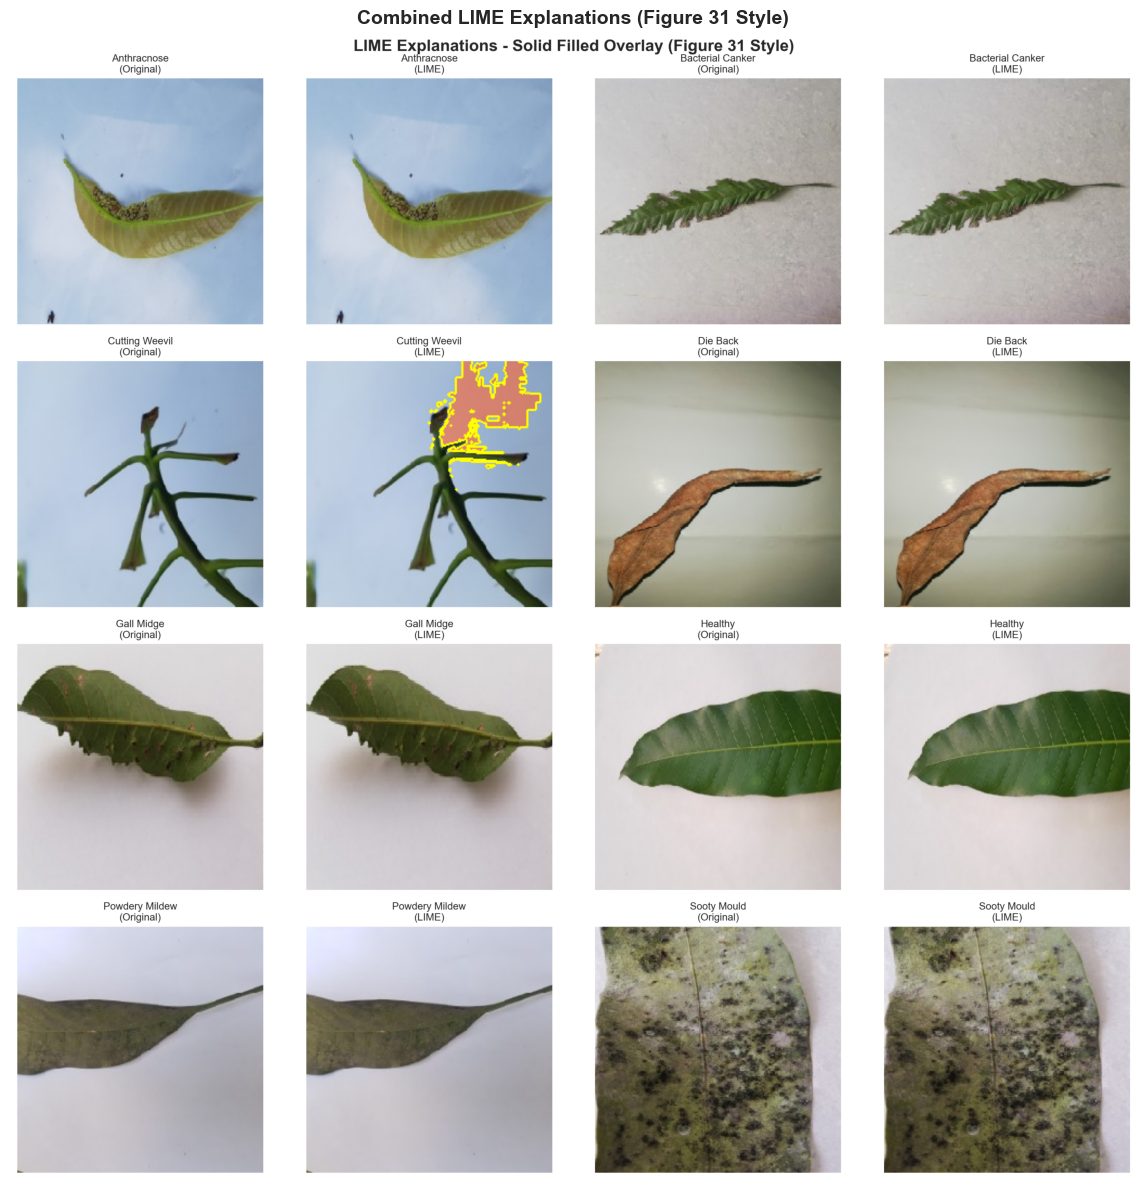


✅ LIME visualization display complete


In [150]:
# DISPLAY GENERATED LIME VISUALIZATIONS
# ============================================

print("=" * 80)
print("📊 DISPLAYING LIME EXPLANATION VISUALIZATIONS")
print("=" * 80)

# Display individual LIME images
lime_images = sorted(LIME_DIR.glob('LIME_*.png')) if LIME_DIR.exists() else []

# Filter out combined figures for individual display
individual_lime = [img for img in lime_images if 'Combined' not in img.name and 'combined' not in img.name]

""" if individual_lime:
    print(f"\nFound {len(individual_lime)} individual LIME explanation images")
    
    # Display all LIME explanations in a grid
    num_images = len(individual_lime)
    n_cols = min(3, num_images)
    n_rows = (num_images + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten() if num_images > 1 else [axes]
    
    for idx, img_path in enumerate(individual_lime):
        img = Image.open(img_path)
        axes[idx].imshow(img)
        # Extract class name from filename
        class_name = img_path.stem.replace('LIME_', '')
        axes[idx].set_title(class_name, fontsize=11, fontweight='bold')
        axes[idx].axis('off')
    
    # Hide unused axes
    for idx in range(num_images, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('LIME Explanations for Mango Leaf Disease Classification', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
 """
# Display combined LIME figure if exists
combined_lime = list(LIME_DIR.glob('*Combined*.png')) + list(LIME_DIR.glob('*combined*.png'))
if combined_lime:
    print(f"\n📄 Combined LIME Figure:")
    fig, ax = plt.subplots(figsize=(16, 12))
    img = Image.open(combined_lime[0])
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('Combined LIME Explanations (Figure 31 Style)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ No combined LIME figure found")

print("\n✅ LIME visualization display complete")

### 9.9 XAI Analysis Summary

Generate a comprehensive summary of all XAI analyses performed.

In [ ]:
# ============================================
# XAI Analysis Summary
# ============================================

print("=" * 70)
print("EXPLAINABLE AI (XAI) ANALYSIS SUMMARY")
print("=" * 70)

# Ensure results dictionaries exist
if 'saliency_results' not in dir() or saliency_results is None:
    saliency_results = {}
if 'lime_results' not in dir() or lime_results is None:
    lime_results = {}

# Compile all results
all_results = {
    'Saliency': saliency_results,
    'LIME': lime_results
}

# Summary statistics
summary_data = []

for method, results in all_results.items():
    if not results:
        summary_data.append({
            'Method': method,
            'Total Images': 0,
            'Correct Predictions': 0,
            'Accuracy (%)': 0.0
        })
        continue
        
    total_images = len(results)
    correct_predictions = sum(1 for r in results.values() if r.get('correct', False))
    
    accuracy = correct_predictions / total_images * 100 if total_images > 0 else 0
    summary_data.append({
        'Method': method,
        'Total Images': total_images,
        'Correct Predictions': correct_predictions,
        'Accuracy (%)': accuracy
    })

summary_df = pd.DataFrame(summary_data)
print("\n📊 XAI Method Summary:")
print("-" * 50)
print(summary_df.to_string(index=False))

# Per-class breakdown
print("\n\n📋 Per-Class Breakdown:")
print("-" * 70)

for method, results in all_results.items():
    print(f"\n{method}:")
    if not results:
        print("  No results available")
        continue
    for class_name, result in results.items():
        correct = result.get('correct', False)
        conf = result.get('confidence', 0)
        status = '✓ Correct' if correct else '✗ Incorrect'
        error_msg = f" (Error: {result.get('error', '')})" if 'error' in result else ""
        print(f"  {class_name}: {status}, Confidence: {conf:.2%}{error_msg}")

# Save comprehensive XAI summary report
xai_summary_path = OUTPUT_DIR / 'xai_summary_report.json'

xai_summary = {
    'dataset': DATASET_NAME,
    'model': MODEL_NAME,
    'run': OUTPUT_DIR.name,
    'xai_methods': ['Grad-CAM', 'Saliency Maps', 'LIME'],
    'output_directories': {
        'gradcam': str(GRADCAM_DIR),
        'saliency': str(SALIENCY_DIR),
        'lime': str(LIME_DIR)
    },
    'summary_statistics': summary_data,
    'detailed_results': {
        method: {
            class_name: {k: v for k, v in result.items() if k != 'top_labels'}
            for class_name, result in results.items()
        } for method, results in all_results.items()
    }
}

with open(xai_summary_path, 'w') as f:
    json.dump(xai_summary, f, indent=2, default=str)

print(f"\n\n📁 XAI Summary Report saved to: {xai_summary_path}")

# Create visual summary figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Per-method accuracy
methods = [d['Method'] for d in summary_data]
accuracies = [d['Accuracy (%)'] for d in summary_data]
colors = plt.cm.viridis(np.linspace(0.3, 0.8, len(methods)))
axes[0].bar(methods, accuracies, color=colors)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Model Accuracy on XAI Samples')
axes[0].set_ylim(0, 100)
for i, (method, acc) in enumerate(zip(methods, accuracies)):
    axes[0].text(i, acc + 2, f'{acc:.1f}%', ha='center', fontsize=10)

# Per-class confidence distribution (using Saliency results if available)
if saliency_results:
    class_names_list = list(saliency_results.keys())
    class_confidences = [saliency_results[cn].get('confidence', 0) for cn in class_names_list]
    
    bars = axes[1].bar(class_names_list, class_confidences, color=plt.cm.Set3(np.linspace(0, 1, len(class_names_list))))
    axes[1].set_ylabel('Confidence')
    axes[1].set_title('Prediction Confidence by Class (Saliency)')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_ylim(0, 1)
    for bar, conf in zip(bars, class_confidences):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                     f'{conf:.1%}', ha='center', fontsize=8)
else:
    axes[1].text(0.5, 0.5, 'No Saliency Results', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Prediction Confidence by Class')

# Prediction correctness pie chart
total_correct = sum(d['Correct Predictions'] for d in summary_data)
total_images = sum(d['Total Images'] for d in summary_data)
total_incorrect = total_images - total_correct

if total_images > 0:
    axes[2].pie([total_correct, total_incorrect], 
                labels=['Correct', 'Incorrect'],
                autopct='%1.1f%%',
                colors=['#4CAF50', '#F44336'],
                explode=(0.05, 0))
    axes[2].set_title('Overall Prediction Distribution')
else:
    axes[2].text(0.5, 0.5, 'No data', ha='center', va='center', transform=axes[2].transAxes)
    axes[2].set_title('Overall Prediction Distribution')

plt.suptitle(f'XAI Analysis Summary - {DATASET_NAME}/{MODEL_NAME}', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save summary figure
summary_fig_path = OUTPUT_DIR / 'xai_summary_visualization.png'
plt.savefig(summary_fig_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n📊 Summary visualization saved to: {summary_fig_path}")

# Print output directory structure
print("\n\n📂 XAI Output Directory Structure:")
print("-" * 50)
print(f"{OUTPUT_DIR}/")
print(f"├── XAI/")
print(f"│   ├── Grad-CAM/")
gradcam_count = len([f for f in GRADCAM_DIR.glob('**/*.png')]) if GRADCAM_DIR.exists() else 0
print(f"│   │   └── {gradcam_count} images")
print(f"│   ├── Saliency/")
saliency_count = len([f for f in SALIENCY_DIR.glob('*.png')]) if SALIENCY_DIR.exists() else 0
print(f"│   │   └── {saliency_count} images")
print(f"│   └── LIME/")
lime_count = len([f for f in LIME_DIR.glob('*.png')]) if LIME_DIR.exists() else 0
print(f"│       └── {lime_count} images")
print(f"├── xai_summary_report.json")
print(f"└── xai_summary_visualization.png")

print("\n" + "=" * 70)
print("XAI ANALYSIS COMPLETE")
print("=" * 70)